# Resource-Aware Benchmarking of GHZ-State Fidelity
### Coherence Validation, Readout Mitigation, Zero-Noise Extrapolation and Hardware-Aware Compilation

Author: Praneshraj Tiruppur Nagarajan Dhyaneswar
Tools: Python, Qiskit, Qiskit Aer

**Scope: Controlled simulation and fake-backend compilation. No quantum hardware execution!!**

### Objective

Investigate how reliably GHZ-state fidelity can be estimated from noisy, finite-shot measurements and whether error mitigation improves accuracy enough to justify its additional sampling cost.

I'm trying not just to check whether mitigation increases the reported  fidelity value. **Compare each estimate with a defined reference and account for the extra measurement and calibration shots required to obtain it**

I use two references in the final analysis:

- **Prepared-state reference:** the exact fidelity of the noisy scale-1 state, calculated from its simulated density matrix before analysis rotations and readout.

- **Ideal reference:** fidelity 1.0 for the intended noiseless GHZ-plus state.

The two references answer different questions!! A mitigation method can move an estimate closer to the ideal target while moving it farther from the
noisy state actually prepared.

### Workflow

The notebook builds the benchmark step by step:

1. Prepare GHZ-plus states for 2-5 qubits and verify the ideal populations and target fidelity.
2. Compare GHZ+, GHZ- and a balanced classical mixture to show why computational-basis populations alone cannot fully describe GHZ fidelity.
3. Check the measurement rotations and reconstruct fidelity using endpoint populations and parity measurements which recover the GHZ coherence.
4. Use density-matrix simulation to separate preparation noise from bias introduced by noisy analysis rotations.
5. **Run finite-shot pilots under ideal, readout-only, depolarizing-only and combined-noise conditions.**
6. Calibrate local readout assignment matrices and correct the measured distributions without clipping negative quasi-probabilities.
7. Fold only the GHZ preparation circuit at scales 1, 3,5.. verify that the ideal output remains unchanged and fit linear ZNE estimates.
8. Compare four estimators over 20 matched repetitions for every width: **unmitigated, readout mitigation, ZNE only and readout mitigation plus ZNE**.
9. Compare bias, MAE, RMSE, estimate variation, paired error changes,calibration behaviour and total shot cost.
10. Check how the GHZ circuits are transpiled on **FakeManila** across different optimization levels and forced physical layouts, then compare the final
accuracy and resource trade-offs.

The main benchmark has 80 matched widthrepeat experiments and 320 method-result rows. Within each experiment, all four methods use the same
underlying target measurements. Readout calibration is repeated for every run, so its sampling cost is included in the total-shot comparison.

### Main findings

I compared the four methods over 20 matched repeats for every GHZ width.
**For the noisy prepared-state reference, readout mitigation gave the lowest MAE** for all widths from 2 to 5 qubits. Its MAE stayed between 0.013671 and
0.018029. It also reduced the absolute error compared with the unmitigated result in every matched run.

For GHZ(5), the unmitigated prepared-reference MAE was 0.250655. After readout mitigation, it became 0.015910, which is a 93.65% reduction. The method used 4,096 total shots instead of 3,072 because it included
1,024 calibration shots.

The answer changes when I use fidelity 1.0 as the reference. At GHZ(2),readout mitigation had the lowest ideal-reference MAE. From GHZ(3) to
GHZ(5), readout mitigation plus ZNE gave the lowest ideal-reference MAE.
For GHZ(5), this combined method reached ideal-reference MAE 0.019688 using 10,240 shots. However its MAE against the prepared-state reference
was 0.044976, which was higher than readout mitigation alone.

For the FakeManila compilation check, all optimization levels from 0 to 3 gave the same CX counts and circuit depths for the normal GHZ chains. The controlled layout check was different. For GHZ(3) changing the layout
from [0, 1, 2] to [0, 2, 4] increased the physical CX count from 2 to 8 and the compiled depth from 5 to 11 because the circuit required routing.

### Scope and limitations

Note that these results are for my selected circuits, controlled noise model,calibration approach and shot budgets. This project uses Aer simulation
and FakeManila transpilation. I did not run the circuits on real quantum hardware..

I used independent readout errors on each qubit. For ZNE, I folded only the GHZ preparation circuit at scales 1, 3 and 5. The analysis rotations
and readout were not folded, so the ZNE intercept should not be treated as a completely noise-free measurement result.

The methods use the same shots per target measurement setting, but their total shot costs are different. The results show the average behaviour over
20 repeats, but they do not prove statistical significance. Also, at GHZ(2), readout mitigation had slightly lower ideal-reference MAE, while the
combined method had slightly lower RMSE.

The main point is that a higher fidelity value is not automatically a better estimate. tried to compare every method with a clear reference and include
the measurement and calibration cost before deciding which result is better.


## 1. Environment

In [54]:
# %pip install qiskit qiskit-aer numpy pandas scipy matplotlib seaborn

%pip install -q qiskit qiskit-aer

In [112]:
import os
import sys
import json
import platform
from pathlib import Path
from datetime import datetime, timezone
from importlib.metadata import version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import qiskit
import qiskit_aer  ## provides fast local quantum-circuit simulators

from qiskit import QuantumCircuit, transpile  ## converts/optimizes a circuit for a chosen simulator or hardware backend .. i.e. build and compile circuits
from qiskit.quantum_info import Statevector  ##  |ψ⟩  , representing an exact pure state
from qiskit_aer import AerSimulator  ## to simulate quantum circuits with optional noise
from qiskit_aer.noise import NoiseModel, ReadoutError, depolarizing_error

# NoiseModel: container used to define which noise affects a simulation
# ReadoutError: models mistakes when converting a qubit measurement into a classical 0 or 1
# depolarizing_error: models random X/Y/Z like gate noise with a chosen probability

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())

## Recording versions before using package-specific APIs
for package in ["qiskit", "qiskit-aer", "numpy", "pandas", "scipy", "matplotlib", "seaborn"]:
    print(f"{package}: {version(package)}")

Python: 3.13.16
Platform: Linux-6.6.122+-x86_64-with-glibc2.39
qiskit: 2.5.2
qiskit-aer: 0.17.2
numpy: 2.1.3
pandas: 2.2.3
scipy: 1.16.3
matplotlib: 3.10.0
seaborn: 0.13.2


## 2. Experiment configuration

just retaining initial noise settings


In [113]:
PROJECT_ROOT = Path.cwd() / "q-reliability-lab"  # portable paths

for folder in [PROJECT_ROOT / "results", PROJECT_ROOT / "figures", PROJECT_ROOT / "src", PROJECT_ROOT / "tests"]:
    folder.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "global_seed": 42,
    "qubit_counts": [2, 3, 4, 5],
    "shot_counts": [128, 512, 2048, 8192],
    "default_shots": 2048,
    "repetitions": 30,
    # Pilot settings before running the full benchmark
    "pilot_qubit_counts": [2, 3],
    "pilot_shots": 512,
    "pilot_repetitions": 3,
    # Controlled noise settings
    "readout_p_0_to_1": 0.03,
    "readout_p_1_to_0": 0.05,
    "depolarizing_p1q": 0.002,
    "depolarizing_p2q": 0.015,
    "created_utc": datetime.now(timezone.utc).isoformat(),
}

np.random.seed(CONFIG["global_seed"])  # Seed NumPy randomness
# Aer and transpiler seeds will be supplied explicitly in execution cells

# Saving the current configuration separately from the reference filename
config_path = PROJECT_ROOT / "results" / "advanced_experiment_config.json"

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(CONFIG, f, indent=2)

# Checking if the saved configuration matches the in-memory settings
with open(config_path, encoding="utf-8") as f:
    saved_config = json.load(f)

assert saved_config == CONFIG
assert all((PROJECT_ROOT / folder).is_dir() for folder in ["results", "figures", "src", "tests"])

print("Project root:", PROJECT_ROOT)
print(json.dumps(CONFIG, indent=2))
print("\nConfiguration saved and checked")

Project root: /content/q-reliability-lab
{
  "global_seed": 42,
  "qubit_counts": [
    2,
    3,
    4,
    5
  ],
  "shot_counts": [
    128,
    512,
    2048,
    8192
  ],
  "default_shots": 2048,
  "repetitions": 30,
  "pilot_qubit_counts": [
    2,
    3
  ],
  "pilot_shots": 512,
  "pilot_repetitions": 3,
  "readout_p_0_to_1": 0.03,
  "readout_p_1_to_0": 0.05,
  "depolarizing_p1q": 0.002,
  "depolarizing_p2q": 0.015,
  "created_utc": "2026-10-06T10:18:23.344202+00:00"
}

Configuration saved and checked


## 3. GHZ preparation

Preparing the GHZ+ state:

|GHZ+⟩ = 1/√2 (|00..0⟩ + |11..1⟩)

Obviously the circuit starts with all qubits in zero. Hadamard gate on |0⟩ creates superposition. Then, a chain of CNOT gates prepares the GHZ across all qubits

Prepararion is separate from the measurement
- measure = False , the function returns only the preparation circuit
- measure = True, it also measures qubit q into classical bit q

In [114]:
def make_ghz_circuit(n_qubits: int, measure: bool = True) -> QuantumCircuit:
    """Prepare GHZ-plus with optional computational-basis measurements"""
    if n_qubits < 2:
        raise ValueError("GHZ benchmark requires at least 2 qubits")

    # Adding classical bits only when measurements are requested
    qc = QuantumCircuit(n_qubits, n_qubits if measure else 0)
    qc.h(0)  # Create a superposition on the first qubit

    for qubit in range(n_qubits - 1):
        qc.cx(qubit, qubit + 1)  # Extend the GHZ state along the chain

    if measure:
        qc.measure(range(n_qubits), range(n_qubits))  # Map qubit q to bit q

    return qc


# Inspect two measured examples using the original variable names
bell_circuit = make_ghz_circuit(2, measure=True)
ghz_3 = make_ghz_circuit(3, measure=True)

print("Bell circuit — GHZ(2)")
print(bell_circuit.draw("text"))

print("\nGHZ(3)")
print(ghz_3.draw("text"))


# Check preparation and measurement structure at every configured width
for n_qubits in CONFIG["qubit_counts"]:
    preparation = make_ghz_circuit(n_qubits, measure=False)
    measured = make_ghz_circuit(n_qubits, measure=True)

    assert preparation.num_qubits == n_qubits
    assert preparation.num_clbits == 0
    assert dict(preparation.count_ops()) == {"h": 1, "cx": n_qubits - 1}

    assert measured.num_clbits == n_qubits
    assert dict(measured.count_ops()) == {"h": 1, "cx": n_qubits - 1, "measure": n_qubits}

print("\nGHZ circuit-structure checks passed for widths 2–5")

Bell circuit — GHZ(2)
     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 

GHZ(3)
     ┌───┐          ┌─┐      
q_0: ┤ H ├──■───────┤M├──────
     └───┘┌─┴─┐     └╥┘┌─┐   
q_1: ─────┤ X ├──■───╫─┤M├───
          └───┘┌─┴─┐ ║ └╥┘┌─┐
q_2: ──────────┤ X ├─╫──╫─┤M├
               └───┘ ║  ║ └╥┘
c: 3/════════════════╩══╩══╩═
                     0  1  2 

GHZ circuit-structure checks passed for widths 2–5


## 4. Ideal populations and target overlap

Need to check the state the above circuit prepares.

Calculate the exact statevector without measurements or noise. For ideal |GHZ+⟩, all-zero and all-one outcomes should each have probability 0.5

Note:
- Population metrics is their sum: P_population = P(00...0) + P(11...1).

This is not fidelity because it ignores the relative phase

- So, construct the GHZ+ target directly and calculate: F = |⟨GHZ+|ψ⟩|^2

This checks agreement with the target, including the relative phase. Upon calculation, the population metric and target fidelity should equal 1. These are exact simulation checks, not sampled measurement estimates


In [115]:
ideal_rows = []

for n_qubits in CONFIG["qubit_counts"]:
    qc = make_ghz_circuit(n_qubits, measure=False)
    state = Statevector.from_instruction(qc)  # Calculate=ing the ideal prepared state
    probs = state.probabilities_dict()  # Get computational-basis probabilities

    all_zero = "0" * n_qubits
    all_one = "1" * n_qubits

    # Construct the target independently rather than using the GHZ circuit
    target = np.zeros(2**n_qubits, dtype=complex)
    target[0] = 1 / np.sqrt(2)  # Amplitude of |00...0>
    target[-1] = 1 / np.sqrt(2)  # Positive amplitude of |11...1>

    population_metric = probs.get(all_zero, 0.0) + probs.get(all_one, 0.0)
    target_fidelity = abs(np.vdot(target, state.data))**2  # Squared target overlap

    assert np.isclose(sum(probs.values()), 1.0)
    assert np.isclose(probs.get(all_zero, 0.0), 0.5)
    assert np.isclose(probs.get(all_one, 0.0), 0.5)
    assert np.isclose(population_metric, 1.0)
    assert np.isclose(target_fidelity, 1.0)

    ideal_rows.append({
        "n_qubits": n_qubits,
        "p_all_zero": probs.get(all_zero, 0.0),
        "p_all_one": probs.get(all_one, 0.0),
        "population_metric": population_metric,
        "target_fidelity": target_fidelity,
    })

ideal_df = pd.DataFrame(ideal_rows)
print(ideal_df.round(6).to_string(index=False))
print("\nIdeal population and target-overlap checks passed")

 n_qubits  p_all_zero  p_all_one  population_metric  target_fidelity
        2         0.5        0.5                1.0              1.0
        3         0.5        0.5                1.0              1.0
        4         0.5        0.5                1.0              1.0
        5         0.5        0.5                1.0              1.0

Ideal population and target-overlap checks passed


## 5. Coherence correctness tests

GHZ+ and GHZ- differ only in their relative sign. Z gate on |1⟩ changes GHZ+ to GHZ-

The balaced classical mixture means 50% all-zero and 50% all-one, without a coherent superposition between them. All three states have population metric 1. The fidelities to GHZ+ should be 1,0 and 0.5

Using density matrices since they represent both pure states and classical mixtures.

For the pure GHZ+ target:
- F = ⟨GHZ+|ρ|GHZ+⟩

Inspect ρ[0, -1], the coherence between all-zero and all-one. Its expected value is +0.5, -0.5 and 0

The above are the exact checks before adding rotated measurements or noise


In [59]:
from qiskit.quantum_info import DensityMatrix, state_fidelity

In [116]:
coherence_rows = []  # Store results for each state and qubit count

for n_qubits in CONFIG["qubit_counts"]:
    # Build GHZ-plus, then change its plus sign to minus using Z
    plus_circuit = make_ghz_circuit(n_qubits, measure=False)
    minus_circuit = plus_circuit.copy()
    minus_circuit.z(0)

    # Writing the ideal GHZ-plus amplitudes separately for reference
    target = np.zeros(2**n_qubits, dtype=complex)
    target[0] = target[-1] = 1 / np.sqrt(2)
    target_state = Statevector(target)

    # Mixture: 50% all-zero, 50% all-one, with no coherence between them
    mixture = np.zeros((2**n_qubits, 2**n_qubits), dtype=complex)
    mixture[0, 0] = mixture[-1, -1] = 0.5

    # Use density matrices to represent both superpositions and the mixture
    states = {
        "ghz_plus": DensityMatrix(Statevector.from_instruction(plus_circuit)),
        "ghz_minus": DensityMatrix(Statevector.from_instruction(minus_circuit)),
        "classical_mixture": DensityMatrix(mixture),
    }

    # Expected values in the same order: GHZ-plus, GHZ-minus, mixture
    expected_fidelities = [1.0, 0.0, 0.5]
    expected_coherences = [0.5, -0.5, 0.0]

    # Check each state against its expected values
    for (name, rho), expected_fidelity, expected_coherence in zip(
        states.items(), expected_fidelities, expected_coherences
    ):
        probs = rho.probabilities()  # Probabilities of each bitstring
        population_metric = probs[0] + probs[-1]  # Total probability in all-zero and all-one
        target_fidelity = state_fidelity(target_state, rho)  # Match with GHZ-plus
        coherence = rho.data[0, -1]  # Entry linking all-zero and all-one

        # Stop if the state is invalid or any result differs from expectation
        assert rho.is_valid()
        assert np.isclose(probs[0], 0.5)
        assert np.isclose(probs[-1], 0.5)
        assert np.isclose(population_metric, 1.0)
        assert np.isclose(target_fidelity, expected_fidelity)
        assert np.isclose(coherence, expected_coherence)

        coherence_rows.append({
            "n_qubits": n_qubits,
            "state": name,
            "population_metric": population_metric,
            "target_fidelity": target_fidelity,
            "coherence_real": coherence.real,
            "coherence_imag": coherence.imag,
        })

coherence_df = pd.DataFrame(coherence_rows)
print(coherence_df.round(6).to_string(index=False))
print("\nGHZ-plus, GHZ-minus, and classical-mixture checks passed")

 n_qubits             state  population_metric  target_fidelity  coherence_real  coherence_imag
        2          ghz_plus                1.0              1.0             0.5             0.0
        2         ghz_minus                1.0              0.0            -0.5            -0.0
        2 classical_mixture                1.0              0.5             0.0             0.0
        3          ghz_plus                1.0              1.0             0.5             0.0
        3         ghz_minus                1.0              0.0            -0.5            -0.0
        3 classical_mixture                1.0              0.5             0.0             0.0
        4          ghz_plus                1.0              1.0             0.5             0.0
        4         ghz_minus                1.0              0.0            -0.5            -0.0
        4 classical_mixture                1.0              0.5             0.0             0.0
        5          ghz_plus             

## 6. Population and parity measurements

To check measurement-rotation convention..

Cannot recover coherence from computational-basis populations alone.. we need to rotate the measurement basis.

For θ, measure:
M(θ) = cos(θ)X + sin(θ)Y

Then apply Rz(-θ), then H, before computational-basis measurement.
At θ = 0 this measures X; at θ = π/2 this measures Y.

First test known one-qubit states to verify the rotation sign. The expectation is P(0) - P(1).

These checks use exact probabilities, without shots or noise. After they pass, will use the rotations for GHZ parity.


In [117]:
def equatorial_analysis(n_qubits: int, theta: float) -> QuantumCircuit:
    """Preparing the basis rotation without adding measurements"""
    qc = QuantumCircuit(n_qubits)

    for qubit in range(n_qubits):
        qc.rz(-theta, qubit)  # Select the equatorial measurement angle
        qc.h(qubit)  # Rotate the selected basis into the Z basis

    return qc


# Each entry stores amplitudes, expected X, and expected Y
test_states = {
    "plus_x": ([1, 1], 1.0, 0.0),
    "minus_x": ([1, -1], -1.0, 0.0),
    "plus_y": ([1, 1j], 0.0, 1.0),
    "minus_y": ([1, -1j], 0.0, -1.0),
}

rotation_rows = []

for name, (amplitudes, expected_x, expected_y) in test_states.items():
    test_state = Statevector(
        np.array(amplitudes, dtype=complex) / np.sqrt(2)
    )  # Normalize the two amplitudes to create the test state

    for basis, theta, expected in [
        ("X", 0.0, expected_x),
        ("Y", np.pi / 2, expected_y),
    ]:
        analysis = equatorial_analysis(1, theta)  # Build the basis rotation
        rotated_state = test_state.evolve(analysis)  # Apply it to the test state
        probs = rotated_state.probabilities()  # Calculate exact Z-basis probabilities

        expectation = probs[0] - probs[1]  # Outcome 0 contributes +1; 1 contributes -1
        assert np.isclose(expectation, expected, atol=1e-12)  # Check the rotation sign

        rotation_rows.append({
            "state": name,
            "basis": basis,
            "expectation": expectation,
            "expected": expected,
        })

rotation_df = pd.DataFrame(rotation_rows)
print(rotation_df.round(6).to_string(index=False))

print("\nY-basis analysis rotation")
print(equatorial_analysis(1, np.pi / 2).draw("text"))
print("\nMeasurement-rotation sign checks passed")

  state basis  expectation  expected
 plus_x     X          1.0       1.0
 plus_x     Y          0.0       0.0
minus_x     X         -1.0      -1.0
minus_x     Y         -0.0       0.0
 plus_y     X          0.0       0.0
 plus_y     Y          1.0       1.0
minus_y     X          0.0       0.0
minus_y     Y         -1.0      -1.0

Y-basis analysis rotation
   ┌──────────┐┌───┐
q: ┤ Rz(-π/2) ├┤ H ├
   └──────────┘└───┘

Measurement-rotation sign checks passed


### GHZ(3): Checking the parity-based fidelity

The above checked the rotation sign. Now, we should check whether rotated measurements recover fidelity to GHZ-plus.

Parity is +1 for outcomes with even ones and -1
for outcomes with odd ones.

For three qubits, let angles be 0, π/3 and 2π/3:

**C = [parity(0) - parity(π/3) + parity(2π/3)] / 3**

Then, **F = (P_population + C) / 2**

Keep the sign of C because the target is GHZ-plus.

As usual testing GHZ+, GHZ- and the balanced classical mixture. Their reconstructed fidelities should be 1, 0 and 0.5.

This is an exact-probability check before using sampled counts or noise.

In [118]:
def parity_from_probabilities(probabilities: np.ndarray) -> float:
    """Calculate even-outcome probability minus odd-outcome probability"""
    parity = 0.0

    for index, probability in enumerate(probabilities):
        sign = (-1)**bin(index).count("1")  # Even number of ones gives +1
        parity += sign * probability

    return float(parity)


n_qubits = 3  # keeping the correctness check samall

target = np.zeros(2**n_qubits, dtype=complex)
target[0] = target[-1] = 1 / np.sqrt(2)  # Defining GHZ+ independently
target_state = Statevector(target)

minus = target.copy()
minus[-1] *= -1  # Changing only the relative sign

# Store each density matrix together with its expected fidelity
pilot_states = {
    "ghz_plus": (DensityMatrix(target_state), 1.0),
    "ghz_minus": (DensityMatrix(Statevector(minus)), 0.0),
    "classical_mixture": (DensityMatrix(np.diag(abs(target)**2)), 0.5),  # Classical mixture keeps the endpoint populations but removes coherence
}

parity_check_rows = []

for name, (rho, expected_fidelity) in pilot_states.items():
    probs = rho.probabilities()
    population_metric = probs[0] + probs[-1]  # Add all-zero and all-one probabilities
    parities = []

    for k in range(n_qubits):
        theta = k * np.pi / n_qubits  # Use angles 0, pi/3, and 2pi/3
        analysis = equatorial_analysis(n_qubits, theta)
        rotated_probs = rho.evolve(analysis).probabilities()  # Apply the rotation and get exact probabilities
        parities.append(parity_from_probabilities(rotated_probs))

    coherence_estimate = (parities[0] - parities[1] + parities[2]) / 3  # Recover signed coherence
    fidelity_estimate = (population_metric + coherence_estimate) / 2  # Combine populations and coherence
    reference_fidelity = state_fidelity(target_state, rho)  # Direct state overlap

    assert np.isclose(population_metric, 1.0)
    assert np.isclose(coherence_estimate, 2 * rho.data[0, -1].real)
    assert np.isclose(fidelity_estimate, reference_fidelity)
    assert np.isclose(fidelity_estimate, expected_fidelity)

    parity_check_rows.append({
        "state": name,
        "parities": np.round(parities, 6).tolist(),
        "population_metric": population_metric,
        "coherence_estimate": coherence_estimate,
        "fidelity_estimate": fidelity_estimate,
        "reference_fidelity": reference_fidelity,
    })

parity_check_df = pd.DataFrame(parity_check_rows)
print(parity_check_df.round(6).to_string(index=False))
print("\nGHZ(3) parity-based fidelity checks passed")

            state          parities  population_metric  coherence_estimate  fidelity_estimate  reference_fidelity
         ghz_plus  [1.0, -1.0, 1.0]                1.0                 1.0                1.0                 1.0
        ghz_minus [-1.0, 1.0, -1.0]                1.0                -1.0                0.0                 0.0
classical_mixture   [0.0, 0.0, 0.0]                1.0                 0.0                0.5                 0.5

GHZ(3) parity-based fidelity checks passed


## 7. Exact noisy-state reference

Need a reference for the actual state prepared under gate noise

Reuse the controlled depolarising model:
- Noise after SX gates
- Noise after CX gates
- No noise on RZ or X in this model

Will compile GHZ(3) into the matching gate basis and save its density matrix before any analysis rotations or measurements.

The overlap with GHZ+ gives the noisy prepared-state fidelity. This is an exact reference for my simulation model, not a measurement estimae or claim about real hardware.

Check the ideal reference, then the noisy one. Analysis-rotation noise and readout noise are excluded from this step



In [119]:
COMMON_BASIS_GATES = ["rz", "sx", "x", "cx"]


def build_depolarizing_noise_model(p_1q: float, p_2q: float) -> NoiseModel:
    """Add noise after SX and CX; leave RZ and X noise-free."""
    noise_model = NoiseModel()

    # Create error rules: one-qubit noise for SX, two-qubit noise for CX
    one_qubit_error = depolarizing_error(p_1q, 1)
    two_qubit_error = depolarizing_error(p_2q, 2)

    # Attaching each error rule to its gate wherever that gate is used
    noise_model.add_all_qubit_quantum_error(one_qubit_error, ["sx"])
    noise_model.add_all_qubit_quantum_error(two_qubit_error, ["cx"])

    return noise_model


# Read the two noise strengths from CONFIG
depolarizing_noise_model = build_depolarizing_noise_model(
    CONFIG["depolarizing_p1q"],
    CONFIG["depolarizing_p2q"],
)

n_qubits = 3
preparation = make_ghz_circuit(n_qubits, measure=False)

# Rewriting the circuit using the gate names recognized by our noise model
compiled_preparation = transpile(
    preparation,
    basis_gates=COMMON_BASIS_GATES,
    optimization_level=0,
    seed_transpiler=CONFIG["global_seed"],
)

# Check that preparation has the expected noisy-gate locations
assert compiled_preparation.count_ops().get("sx", 0) == 1
assert compiled_preparation.count_ops().get("cx", 0) == 2

# Take a state snapshot after preparation, before any analysis or measurement
reference_circuit = compiled_preparation.copy()
reference_circuit.save_density_matrix(label="prepared_state")

# Write the ideal GHZ-plus state separately for comparison
target = np.zeros(2**n_qubits, dtype=complex)
target[0] = target[-1] = 1 / np.sqrt(2)
target_state = Statevector(target)

density_references = {}
reference_rows = []

# Run the same circuit twice: perfect gates, then noisy gates
for condition, noise_model in {
    "ideal": None,
    "depolarizing_only": depolarizing_noise_model,
}.items():

    simulator = AerSimulator(
        method="density_matrix",  # Calculate the state directly, including noise
        noise_model=noise_model,
    )

    result = simulator.run(reference_circuit, shots=1).result()
    assert result.success

    # Retrieving the saved state and check that it is a valid density matrix
    rho = DensityMatrix(result.data(0)["prepared_state"])
    assert rho.is_valid()

    # Keeping this state for later comparisons
    density_references[condition] = rho

    probs = rho.probabilities()
    reference_rows.append({
        "noise_condition": condition,
        "population_metric": probs[0] + probs[-1],  # P(000) + P(111)
        "prepared_state_fidelity": state_fidelity(target_state, rho),
    })

# Without noise, compiling the circuit should still produce GHZ-plus
assert np.isclose(state_fidelity(target_state, density_references["ideal"]), 1.0)

reference_df = pd.DataFrame(reference_rows)
print("Compiled preparation gates:", dict(compiled_preparation.count_ops()))
print(reference_df.round(6).to_string(index=False))
print("\nPrepared-state density-matrix references checked")

Compiled preparation gates: {'rz': 2, 'cx': 2, 'sx': 1}
  noise_condition  population_metric  prepared_state_fidelity
            ideal           1.000000                 1.000000
depolarizing_only           0.981363                 0.974824

Prepared-state density-matrix references checked


### Checking the noisy state with ideal analysis rotations

Previously saved the state after noisy preparation.

Will apply ideal measurement-basis rotations to the above saved state and calculate the exact outcome probabilities.

Will reconstruct fidelity using population and rotated parity. It should match the direct density-matrix fidelity.

The purpose is to check that the estimator also works when preparation noise creates a mixed state. No sampled shots, readout noise or
analysis-rotation noise are included yet.

In [120]:
estimator_check_rows = []

for condition, rho in density_references.items():
    # Checking that the state and analysis circuit have the same qubit count
    assert rho.num_qubits == n_qubits

    # Read populations before any analysis rotations
    probs = rho.probabilities()
    population_metric = probs[0] + probs[-1]  # P(all-zero) + P(all-one)
    signed_parities = []

    for k in range(n_qubits):
        # For 3 qubits we use angles 0, pi/3 and 2*pi/3
        theta = k * np.pi / n_qubits
        analysis = equatorial_analysis(n_qubits, theta)

        # Start from the same saved state at every angle, rotations are ideal
        rotated_probs = rho.evolve(analysis).probabilities()
        parity = parity_from_probabilities(rotated_probs)  # P(even) - P(odd)

        # For 3 qubits, weight the parities by +1, -1, +1
        signed_parities.append((-1)**k * parity)

    # Average the weighted parities to recover signed coherence
    coherence_estimate = np.mean(signed_parities)

    # Reconstructing fidelity from populations and coherence
    fidelity_estimate = (population_metric + coherence_estimate) / 2

    # Calculating fidelity directly from the saved state for comparison
    reference_fidelity = state_fidelity(target_state, rho)

    # Check that parity measurements recovered the correct coherence
    assert np.isclose(coherence_estimate, 2 * rho.data[0, -1].real, atol=1e-12)

    # Check that reconstructed and direct fidelities agree
    assert np.isclose(fidelity_estimate, reference_fidelity, atol=1e-12)

    estimator_check_rows.append({
        "noise_condition": condition,
        "population_metric": population_metric,
        "coherence_estimate": coherence_estimate,
        "fidelity_estimate": fidelity_estimate,
        "reference_fidelity": reference_fidelity,
        "difference": fidelity_estimate - reference_fidelity,
    })

estimator_check_df = pd.DataFrame(estimator_check_rows)
print(estimator_check_df.round(6).to_string(index=False))
print("\nNoisy-state fidelity reconstruction with ideal rotations passed")

  noise_condition  population_metric  coherence_estimate  fidelity_estimate  reference_fidelity  difference
            ideal           1.000000            1.000000           1.000000            1.000000         0.0
depolarizing_only           0.981363            0.968285           0.974824            0.974824        -0.0

Noisy-state fidelity reconstruction with ideal rotations passed


### When analysis rotations are noisy???? check

The above estimator matched the reference when analysis rotations were ideal.

Now, from the same saved noisy state, apply noisy
analysis rotations. This isolates analysis noise from preparation noise.

I will compile the rotations into the existing gate basis. The SX gates will receive depolarizing noise; RZ remains noise-free under my chosen model.

Keep the population measurement ideal for this isolated test. There is still no readout noise or shot sampling.

The reconstructed fidelity may differ from the prepared-state reference.
That difference is analysis bias, not a change to the saved prepared state.

In [121]:
# Using the same saved noisy state..dont prepare GHZ again
rho_prepared = density_references["depolarizing_only"]
n_qubits = rho_prepared.num_qubits

# Add gate noise during the analysis rotations!
analysis_simulator = AerSimulator(
    method="density_matrix",
    noise_model=depolarizing_noise_model,
)

noisy_parity_rows = []
signed_parities = []

for k in range(n_qubits):
    # For 3 qubits, angles 0, pi/3 and 2*pi/3
    theta = k * np.pi / n_qubits
    analysis = equatorial_analysis(n_qubits, theta)

    # Rewrite H using SX so our SX noise rule is applied
    compiled_analysis = transpile(
        analysis,
        basis_gates=COMMON_BASIS_GATES,
        optimization_level=0,
        seed_transpiler=CONFIG["global_seed"],
    )

    operations = compiled_analysis.count_ops()

    # One noisy SX per qubit; no GHZ preparation gates are rerun
    assert operations.get("sx", 0) == n_qubits
    assert operations.get("cx", 0) == 0

    # Start every angle from the same prepared state
    analysis_circuit = QuantumCircuit(n_qubits)
    analysis_circuit.set_density_matrix(rho_prepared)

    # Apply noisy analysis rotations, then save the resulting state
    analysis_circuit.compose(compiled_analysis, inplace=True)
    analysis_circuit.save_density_matrix(label="after_analysis")

    result = analysis_simulator.run(analysis_circuit, shots=1).result()
    assert result.success

    rho_after_analysis = DensityMatrix(
        result.data(0)["after_analysis"]
    )
    assert rho_after_analysis.is_valid()

    # Calculate parity from exact probabilities after noisy rotations
    parity = parity_from_probabilities(
        rho_after_analysis.probabilities()
    )

    # For 3 qubits, use weights +1, -1, +1
    signed_parities.append((-1)**k * parity)

    noisy_parity_rows.append({
        "k": k,
        "parity": parity,
        "sx_gate_count": operations.get("sx", 0),
    })

# Population comes from the original state, before analysis rotations
probs = rho_prepared.probabilities()
population_metric = probs[0] + probs[-1]

# Reconstruct fidelity using the noisy parity results
coherence_estimate = np.mean(signed_parities)
noisy_analysis_fidelity = (
    population_metric + coherence_estimate
) / 2

# True fidelity of the original prepared state
reference_fidelity = state_fidelity(target_state, rho_prepared)

# Retrieving the earlier estimate using perfect analysis rotations
ideal_analysis_fidelity = estimator_check_df.loc[
    estimator_check_df["noise_condition"] == "depolarizing_only",
    "fidelity_estimate",
].iloc[0]

# Compare two analysis methods against the same prepared-state reference
analysis_comparison_df = pd.DataFrame({
    "analysis_rotations": ["ideal", "noisy"],
    "fidelity_estimate": [
        ideal_analysis_fidelity,
        noisy_analysis_fidelity,
    ],
    "prepared_state_fidelity": [
        reference_fidelity,
        reference_fidelity,
    ],
})

# Negative bias means the estimate is below the true prepared fidelity
analysis_comparison_df["analysis_bias"] = (
    analysis_comparison_df["fidelity_estimate"]
    - analysis_comparison_df["prepared_state_fidelity"]
)

print(pd.DataFrame(noisy_parity_rows).round(6).to_string(index=False))
print("\nAnalysis-rotation comparison")
print(analysis_comparison_df.round(6).to_string(index=False))

 k    parity  sx_gate_count
 0  0.962486              3
 1 -0.962486              3
 2  0.962486              3

Analysis-rotation comparison
analysis_rotations  fidelity_estimate  prepared_state_fidelity  analysis_bias
             ideal           0.974824                 0.974824      -0.000000
             noisy           0.971924                 0.974824      -0.002899


## 8. Controlled noise baseline

First step --> sampled ideal GHZ(3)

Till now, exact states and probabilities were calculated. Need to execute measured circuits and collect finite-shot counts.

One shot --> prepare the circuit and measure the qubits once  (Eg: 69 shots produce 69 recorded bitstrings)

Will use four measurement settings:
- One computational-basis setting for population
- 3 rotated settings for parity

 Will reconstruct fidelity from the measured counts and keep the raw counts, seeds and compiled circuits for later checks.

 The first pilot has no noise. After it works, will reuse the same circuits under readout-only, depolarising-only and combined noise.

  Note: Ideal GHZ+ has deterministic parity at these particular angles, so its fidelity can remain exactly 1 even with finite shots. The split between 000 and 111 can still fluctuate


In [122]:
def counts_to_probability_vector(counts: dict, n_qubits: int) -> np.ndarray:
    """Convert bitstring counts to probabilities: count / total shots"""
    total_shots = sum(counts.values())
    if total_shots <= 0:
        raise ValueError("No measurement shots were returned")

    probabilities = np.zeros(2**n_qubits)  # One slot per possible bitstring

    for bitstring, count in counts.items():
        bitstring = bitstring.replace(" ", "")  # Remove spaces between registers
        assert len(bitstring) == n_qubits
        index = int(bitstring, 2)  # Binary "101" becomes index 5
        probabilities[index] = count / total_shots

    return probabilities


n_qubits = 3
shots = CONFIG["pilot_shots"]
ideal_simulator = AerSimulator(method="density_matrix")

# Measure populations without rotation; parity at 0, pi/3, and 2*pi/3
measurement_settings = {"population": None}
for k in range(n_qubits):
    measurement_settings[f"parity_{k}"] = k * np.pi / n_qubits

pilot_compiled_circuits = {}
pilot_counts = {}
pilot_measurement_rows = []

for setting_index, (setting, theta) in enumerate(measurement_settings.items()):
    circuit = QuantumCircuit(n_qubits, n_qubits)
    circuit.compose(compiled_preparation, inplace=True)  # Reuse GHZ preparation
    circuit.barrier()  # Separate preparation from analysis

    if theta is not None:
        # Rotate the measurement basis only for parity settings
        circuit.compose(
            equatorial_analysis(n_qubits, theta), inplace=True
        )

    circuit.measure(range(n_qubits), range(n_qubits))  # Qubit q → classical bit q

    compiled = transpile(
        circuit,
        basis_gates=COMMON_BASIS_GATES,
        optimization_level=0,
        seed_transpiler=CONFIG["global_seed"],
    )
    pilot_compiled_circuits[setting] = compiled  # Keep for later noisy runs

    # Using a separate, repeatable sampling seed for each setting
    seed = CONFIG["global_seed"] + 90_000 + setting_index
    result = ideal_simulator.run(
        compiled,
        shots=shots,
        seed_simulator=seed,
    ).result()
    assert result.success

    counts = result.get_counts()
    assert sum(counts.values()) == shots  # Check that every shot was recorded
    pilot_counts[setting] = counts

    # Record counts and run details for later inspection
    pilot_measurement_rows.append({
        "noise_condition": "ideal",
        "n_qubits": n_qubits,
        "setting": setting,
        "theta": theta,
        "shots": sum(counts.values()),
        "seed_simulator": seed,
        "transpiled_depth": compiled.depth(),
        "operations_json": json.dumps(dict(compiled.count_ops())),
        "counts_json": json.dumps(dict(sorted(counts.items()))),
    })

# Estimate population: P(000) + P(111)
probs = counts_to_probability_vector(pilot_counts["population"], n_qubits)
population_estimate = probs[0] + probs[-1]

# Estimate coherence using parity weights +1, -1, +1
signed_parities = []
for k in range(n_qubits):
    probs = counts_to_probability_vector(pilot_counts[f"parity_{k}"], n_qubits)
    parity = parity_from_probabilities(probs)  # P(even) - P(odd)
    signed_parities.append((-1)**k * parity)

coherence_estimate = np.mean(signed_parities)
fidelity_estimate = (population_estimate + coherence_estimate) / 2

# Ideal GHZ-plus should pass all three checks
assert np.isclose(population_estimate, 1.0)
assert np.isclose(coherence_estimate, 1.0)
assert np.isclose(fidelity_estimate, 1.0)

# Saving sampled counts, run details,final fidelity
pilot_measurement_df = pd.DataFrame(pilot_measurement_rows)
pilot_measurement_df.to_csv(
    PROJECT_ROOT / "results" / "ideal_ghz3_sampled_pilot.csv",
    index=False,
)

print("Population counts:", dict(sorted(pilot_counts["population"].items())))
print(pilot_measurement_df[["setting", "shots"]].to_string(index=False))
print("Total target shots:", pilot_measurement_df["shots"].sum())
print(f"Population estimate: {population_estimate:.6f}")
print(f"Coherence estimate:  {coherence_estimate:.6f}")
print(f"Fidelity estimate:   {fidelity_estimate:.6f}")
print("\nIdeal sampled GHZ(3) pilot passed")

Population counts: {'000': 252, '111': 260}
   setting  shots
population    512
  parity_0    512
  parity_1    512
  parity_2    512
Total target shots: 2048
Population estimate: 1.000000
Coherence estimate:  1.000000
Fidelity estimate:   1.000000

Ideal sampled GHZ(3) pilot passed


### Controlled-noise comparison

Reuse the same four compiled GHZ(3) measurement circuits.

To execute
- Readout-only noise
- Depolarizing-only noise
- Combined noise

Readout errors are independent across qubits:
a true 0 can be recorded as 1, and a true 1 as 0.

Gate noise affects both preparation and analysis SX gates plus the preparation CX gates.

I will compare raw measurement estimates with prepared-state references.
Their differences can include sampling error, readout error and analysis-rotation error. One pilot is not enough to establish bias or statistical significance.

No mitigation is applied yet. I will preserve raw counts and seeds,
without clipping the estimates.

In [123]:
def build_readout_noise_model(p_0_to_1: float, p_1_to_0: float) -> NoiseModel:
    """Add independent bit-recording errors to every qubit."""
    readout_error = ReadoutError([
        [1 - p_0_to_1, p_0_to_1],  # True 0: record 0 or 1
        [p_1_to_0, 1 - p_1_to_0],  # True 1: record 0 or 1
    ])
    noise_model = NoiseModel()
    noise_model.add_all_qubit_readout_error(readout_error)
    return noise_model


def build_combined_noise_model(p_0_to_1: float, p_1_to_0: float, p_1q: float, p_2q: float) -> NoiseModel:
    """Combine noisy gates with incorrect measurement recording."""
    # Start with the existing SX and CX depolarizing errors
    noise_model = build_depolarizing_noise_model(p_1q, p_2q)
    readout_error = ReadoutError([
        [1 - p_0_to_1, p_0_to_1],
        [p_1_to_0, 1 - p_1_to_0],
    ])
    noise_model.add_all_qubit_readout_error(readout_error)
    return noise_model


# Build readout-only and combined models using CONFIG
readout_noise_model = build_readout_noise_model(
    CONFIG["readout_p_0_to_1"], CONFIG["readout_p_1_to_0"]
)
combined_noise_model = build_combined_noise_model(
    CONFIG["readout_p_0_to_1"],
    CONFIG["readout_p_1_to_0"],
    CONFIG["depolarizing_p1q"],
    CONFIG["depolarizing_p2q"],
)

FORMAL_NOISE_CONDITIONS = {
    "ideal": None,
    "readout_only": readout_noise_model,
    "depolarizing_only": depolarizing_noise_model,
    "combined": combined_noise_model,
}

n_qubits, shots = 3, CONFIG["pilot_shots"]

# Reusing the ideal counts and run details already collected
controlled_pilot_counts = {"ideal": pilot_counts}
controlled_measurement_rows = pilot_measurement_df.to_dict("records")

for condition_index, (condition, noise_model) in enumerate(FORMAL_NOISE_CONDITIONS.items()):
    if condition == "ideal":
        continue  # Ideal runs are already finished

    # Enable the selected noise model
    simulator = AerSimulator(method="density_matrix", noise_model=noise_model)
    controlled_pilot_counts[condition] = {}

    for setting_index, (setting, compiled) in enumerate(pilot_compiled_circuits.items()):
        # Use a repeatable seed for each condition and measurement setting
        seed = CONFIG["global_seed"] + 91_000 + condition_index * 100 + setting_index

        # Run the same compiled circuit; change only noise and sampling seed
        result = simulator.run(compiled, shots=shots, seed_simulator=seed).result()
        assert result.success

        counts = result.get_counts()
        assert sum(counts.values()) == shots  # Check all shots were recorded
        controlled_pilot_counts[condition][setting] = counts

        # Keep raw counts and run details for later analysis
        controlled_measurement_rows.append({
            "noise_condition": condition,
            "n_qubits": n_qubits,
            "setting": setting,
            "theta": measurement_settings[setting],
            "shots": sum(counts.values()),
            "seed_simulator": seed,
            "transpiled_depth": compiled.depth(),
            "operations_json": json.dumps(dict(compiled.count_ops())),
            "counts_json": json.dumps(dict(sorted(counts.items()))),
        })

# Match each condition to its state BEFORE analysis and measurement
# Readout errors do not change this prepared-state reference
prepared_state_references = {
    "ideal": density_references["ideal"],
    "readout_only": density_references["ideal"],
    "depolarizing_only": density_references["depolarizing_only"],
    "combined": density_references["depolarizing_only"],
}

controlled_summary_rows = []

for condition, setting_counts in controlled_pilot_counts.items():
    # Estimate population from the unrotated measurement counts
    probs = counts_to_probability_vector(setting_counts["population"], n_qubits)
    population_estimate = probs[0] + probs[-1]  # P(000) + P(111)
    signed_parities = []

    for k in range(n_qubits):
        probs = counts_to_probability_vector(setting_counts[f"parity_{k}"], n_qubits)
        parity = parity_from_probabilities(probs)  # P(even) - P(odd)
        signed_parities.append((-1)**k * parity)  # Weights: +1, -1, +1

    # Reconstruct raw fidelity without correcting or clipping it
    coherence_estimate = np.mean(signed_parities)
    fidelity_estimate = (population_estimate + coherence_estimate) / 2

    # Direct fidelity of the matching saved preparation state
    reference_fidelity = state_fidelity(
        target_state, prepared_state_references[condition]
    )

    controlled_summary_rows.append({
        "noise_condition": condition,
        "population_estimate": population_estimate,
        "coherence_estimate": coherence_estimate,
        "raw_fidelity_estimate": fidelity_estimate,
        "prepared_state_fidelity": reference_fidelity,
        # Difference may include sampling, readout, and analysis errors
        "estimate_minus_reference": fidelity_estimate - reference_fidelity,
        # Total shots across population and all parity settings
        "target_shots": sum(sum(c.values()) for c in setting_counts.values()),
    })

controlled_measurement_df = pd.DataFrame(controlled_measurement_rows)
controlled_summary_df = pd.DataFrame(controlled_summary_rows)

# Expect one row per condition and setting: 4 × 4 = 16
assert len(controlled_measurement_df) == (
    len(FORMAL_NOISE_CONDITIONS) * len(pilot_compiled_circuits)
)

# Save both the raw evidence and the reconstructed results
controlled_measurement_df.to_csv(
    PROJECT_ROOT / "results" / "controlled_ghz3_pilot_raw.csv", index=False
)
controlled_summary_df.to_csv(
    PROJECT_ROOT / "results" / "controlled_ghz3_pilot_summary.csv", index=False
)

print(controlled_summary_df.round(6).to_string(index=False))
print("\nTotal target shots:", controlled_measurement_df["shots"].sum())
print("Controlled-noise pilot completed — no mitigation applied")

  noise_condition  population_estimate  coherence_estimate  raw_fidelity_estimate  prepared_state_fidelity  estimate_minus_reference  target_shots
            ideal             1.000000            1.000000               1.000000                 1.000000                  0.000000          2048
     readout_only             0.888672            0.751302               0.819987                 1.000000                 -0.180013          2048
depolarizing_only             0.978516            0.960938               0.969727                 0.974824                 -0.005097          2048
         combined             0.876953            0.733073               0.805013                 0.974824                 -0.169811          2048

Total target shots: 8192
Controlled-noise pilot completed — no mitigation applied


### Dephasing: populations can hide damage

Will start from ideal GHZ(3) and apply a random Z error to qubit 0 after preparation.

With probability p, Z changes GHZ+ into GHZ-
With probability 1 - p, the state stays GHZ-plus

The all-zero and all-one populations do not change.
However, the signed coherence and GHZ-plus fidelity change

P_population = 1
C = 1 - 2p
F = 1 - p

At p = 0.5, coherence disappears and fidelity becomes 0.5, although the population metric still reports 1.

This is a small exact channel check, without readout noise, analysis noise or sampled shots.

In [124]:
from qiskit_aer.noise import pauli_error

# Start from the ideal GHZ-plus state: (|000> + |111>) / sqrt(2)
rho_ideal = density_references["ideal"]
dephasing_rows = []

for p in [0.0, 0.1, 0.5]:
    phase_flip = pauli_error([
        ("Z", p),  # With probability p, apply Z and flip the GHZ relative sign
        ("I", 1 - p),  # With probability 1 - p, do nothing (I = identity)
    ])

    # Apply this noise only to qubit 0.
    # For GHZ, Z on any one qubit changes GHZ-plus to GHZ-minus.
    rho = rho_ideal.evolve(
        phase_flip.to_quantumchannel(),
        qargs=[0],
    )

    assert rho.is_valid()  # Check that rho is a valid density matrix

    probs = rho.probabilities()   # Direct computational-basis probabilities
    population_metric = probs[0] + probs[-1]    # Population in the two desired GHZ bitstrings: P(000) + P(111)
    coherence = 2 * rho.data[0, -1].real      # Coherence between |000> and |111> ; Multiply by 2 because rho[0, -1] is +0.5 for ideal GHZ-plus
    fidelity = state_fidelity(target_state, rho)   # Full agreement with the GHZ-plus target, including relative phase

    assert np.isclose(population_metric, 1.0)     # A phase flip changes phase, not the 000/111 populations
    assert np.isclose(coherence, 1 - 2 * p)      # Expected coherence: +1 at p=0, 0 at p=0.5, -1 at p=1
    assert np.isclose(fidelity, 1 - p)  # Expected GHZ-plus fidelity: 1 at p=0, 0.5 at p=0.5, 0 at p=1

    # GHZ-plus fidelity = (population + signed coherence) / 2
    assert np.isclose(
        fidelity,
        (population_metric + coherence) / 2,
    )

    dephasing_rows.append({
        "phase_flip_probability": p,
        "population_metric": population_metric,
        "coherence": coherence,
        "prepared_state_fidelity": fidelity,
    })

dephasing_df = pd.DataFrame(dephasing_rows)
dephasing_df.to_csv(
    PROJECT_ROOT / "results" / "ghz3_dephasing_check.csv",
    index=False,
)

print(dephasing_df.round(6).to_string(index=False))
print("\nDephasing check passed — populations alone miss coherence loss")

 phase_flip_probability  population_metric  coherence  prepared_state_fidelity
                    0.0                1.0        1.0                      1.0
                    0.1                1.0        0.8                      0.9
                    0.5                1.0        0.0                      0.5

Dephasing check passed — populations alone miss coherence loss


## 9. Readout calibration and correction

### Calibrating local readout errors

Need to calibrate readout error before correcting GHZ counts. For each qubit, prepare known all-zero and all-one states, measure them and estimate a local 2 x 2 assignment matrix.

Rows --> recorded outcomes; columns --> true prepared values

A_q = [[P(0|0), P(0|1)],
       [P(1|0), P(1|1)]]

Using the same three qubits and readout-noise conditions as the GHZ(3) pilot. Assume independent readout errors across qubits.

The two calibration circuits identify local marginals, not a complete correlated three-qubit readout model.

Calibration costs extra shots. Will record these shots separately from the four GHZ measurement settings


In [125]:
CALIBRATION_QUBITS = n_qubits
CALIBRATION_SHOTS = CONFIG["pilot_shots"]


def make_calibration_circuit(n_qubits: int, prepared_bit: int) -> QuantumCircuit:
    """Prepare all zeros or all ones, then measure every qubit"""
    qc = QuantumCircuit(n_qubits, n_qubits)

    if prepared_bit == 1:
        qc.x(range(n_qubits))  # Prepare |11...1> instead of |00...0>

    qc.measure(range(n_qubits), range(n_qubits))  # Map qubit q to bit q
    return qc


def marginal_p_zero(counts: dict, n_qubits: int, qubit: int) -> float:
    """Estimate the probability that one selected qubit was recorded as 0"""
    total_shots = sum(counts.values())
    if total_shots <= 0:
        raise ValueError("No calibration shots were returned")

    position = n_qubits - 1 - qubit  # Qiskit prints c[n-1] on the left

    zero_count = sum(
        count
        for bitstring, count in counts.items()
        if bitstring.replace(" ", "")[position] == "0"
    )

    return zero_count / total_shots


# Using readout-only noise because calibration measures readout assignment errors
calibration_simulator = AerSimulator(
    method="density_matrix",
    noise_model=readout_noise_model,
)

calibration_counts = {}

# Run two known calibration states: all zeros and all ones
for prepared_bit in [0, 1]:
    calibration_circuit = make_calibration_circuit(
        CALIBRATION_QUBITS,
        prepared_bit,
    )  # Prepare |000> when 0, or |111> when 1

    compiled_calibration = transpile(
        calibration_circuit,
        basis_gates=COMMON_BASIS_GATES,
        optimization_level=0,
        seed_transpiler=CONFIG["global_seed"],
    )  # Compile into the same gate basis used in this project

    seed = CONFIG["global_seed"] + 92_000 + prepared_bit  # Fixed different seed per known input
    result = calibration_simulator.run(
        compiled_calibration,
        shots=CALIBRATION_SHOTS,
        seed_simulator=seed,
    ).result()  # Sample noisy readout outcomes for the known input state

    assert result.success  # Stop if Aer did not complete the calibration circuit

    counts = result.get_counts()
    assert sum(counts.values()) == CALIBRATION_SHOTS  # Confirm no shots are missing
    calibration_counts[prepared_bit] = counts  # Save counts for local-matrix estimation


assignment_matrices = []  # Store one 2 x 2 readout matrix per qubit
calibration_rows = []  # Store readable calibration values for the results table


# Estimate the local readout behavior of every measured qubit
for qubit in range(CALIBRATION_QUBITS):
    p_0_given_0 = marginal_p_zero(
        calibration_counts[0],
        CALIBRATION_QUBITS,
        qubit,
    )  # Estimate P(record 0 | true 0)

    p_0_given_1 = marginal_p_zero(
        calibration_counts[1],
        CALIBRATION_QUBITS,
        qubit,
    )  # Estimate P(record 0 | true 1)

    assignment_matrix = np.array([
        [p_0_given_0, p_0_given_1],
        [1 - p_0_given_0, 1 - p_0_given_1],
    ])  # Rows are recorded 0/1; columns are true prepared 0/1

    assert np.allclose(
        assignment_matrix.sum(axis=0), 1.0
    )  # Each true input must be recorded as either 0 or 1

    assignment_matrices.append(assignment_matrix)  # Keep the matrix for global correction

    calibration_rows.append({
        "qubit": qubit,
        "P(0|0)": p_0_given_0,
        "P(1|0)": 1 - p_0_given_0,
        "P(0|1)": p_0_given_1,
        "P(1|1)": 1 - p_0_given_1,
        "condition_number": np.linalg.cond(assignment_matrix),  # Larger values mean less stable inversion
    })


calibration_df = pd.DataFrame(calibration_rows)  # Convert results into a readable table


# Save the estimated matrices so the correction can be reproduced later
calibration_df.to_csv(
    PROJECT_ROOT / "results" / "ghz3_readout_calibration.csv",
    index=False,
)


print("Calibration counts for |000>:", dict(sorted(calibration_counts[0].items())))
print("Calibration counts for |111>:", dict(sorted(calibration_counts[1].items())))
print("\nLocal assignment matrices")
print(calibration_df.round(6).to_string(index=False))
print(f"\nCalibration shots: {2 * CALIBRATION_SHOTS}\n")
print("Local readout calibration passed")

Calibration counts for |000>: {'000': 472, '001': 9, '010': 15, '011': 1, '100': 13, '101': 1, '110': 1}
Calibration counts for |111>: {'001': 2, '011': 21, '101': 17, '110': 23, '111': 449}

Local assignment matrices
 qubit   P(0|0)   P(1|0)   P(0|1)   P(1|1)  condition_number
     0 0.978516 0.021484 0.044922 0.955078          1.075587
     1 0.966797 0.033203 0.037109 0.962891          1.075751
     2 0.970703 0.029297 0.044922 0.955078          1.081995

Calibration shots: 1024

Local readout calibration passed



### Correct all GHZ measurement settings

Have estimated one local readout assignment matrix per qubit.

Will combine the three local matrices into one 8 x 8 global matrix. It maps the true three-qubit distribution to the recorded distribution:

**p_observed = A_global x p_true**

For each GHZ measurement setting, we solve:

**A_global x p_corrected = p_observed**

Correct all four GHZ settings:
- Population
- Parity at 0
- Parity at π/3
- Parity at 2π/3

The corrected values are quasi-probabilities. They can be negative or above 1 because matrix inversion amplifies finite-shot uncertainty. Will keep these values as diagnostics and will not clip them.

First correct the readout-only pilot, where the prepared-state reference is 1. Then use the same method for combined noise.

In [126]:
def build_global_assignment_matrix(local_matrices: list) -> np.ndarray:
    """Combine one 2x2 readout matrix per qubit into one full 2^n x 2^n matrix."""
    # Qiskit displays the highest-index qubit on the left of a bitstring.
    # Start with qubit n-1 so matrix rows/columns match printed bitstrings.
    global_matrix = local_matrices[-1]

    # Kronecker product combines independent readout errors across qubits
    for local_matrix in reversed(local_matrices[:-1]):
        global_matrix = np.kron(global_matrix, local_matrix)

    return global_matrix


# For GHZ(3), combine three 2x2 matrices into one 8x8 readout model
global_assignment_matrix = build_global_assignment_matrix(assignment_matrices)

# Check that the matrix has one row/column for every 3-qubit bitstring
assert global_assignment_matrix.shape == (2**n_qubits, 2**n_qubits)

# Each column describes outcomes from one true bitstring, so it must sum to 1
assert np.allclose(global_assignment_matrix.sum(axis=0), 1.0)

# Large condition number means inversion may strongly amplify sampling noise
global_condition_number = np.linalg.cond(global_assignment_matrix)

print(
    f"Global assignment-matrix condition number: "
    f"{global_condition_number:.6f}"
)


def mitigate_counts(counts: dict, n_qubits: int) -> np.ndarray:
    """Estimate pre-readout probabilities from observed measurement counts"""
    # Convert raw sampled counts, such as {"000": 900, "111": 100} into the observed probability vector p_observed.
    observed_probabilities = counts_to_probability_vector(counts, n_qubits)

    # Readout model: p_observed = A_global @ p_true
    # Solve for p_true, the estimated distribution before detector errors
    return np.linalg.solve(global_assignment_matrix, observed_probabilities)


mitigation_rows = []

# Apply readout mitigation only where readout noise exists.
for condition in ["readout_only", "combined"]:
    setting_counts = controlled_pilot_counts[condition]

    # ----- Population setting: no analysis rotation -----

    # Raw measured Z-basis probabilities
    raw_probs = counts_to_probability_vector(
        setting_counts["population"], n_qubits
    )

    # Estimated Z-basis probabilities before readout mistakes
    corrected_probs = mitigate_counts(
        setting_counts["population"], n_qubits
    )

    # GHZ population = probability of 000 plus probability of 111
    raw_population = raw_probs[0] + raw_probs[-1]
    corrected_population = corrected_probs[0] + corrected_probs[-1]

    raw_signed_parities = []
    corrected_signed_parities = []

    # Track any negative corrected entries. They can occur because inverse correction creates quasi-probabilities
    minimum_quasi_probability = corrected_probs.min()

    # ----- Parity settings: angles 0, pi/3, 2*pi/3 -----
    for k in range(n_qubits):
        setting = f"parity_{k}"

        # Convert raw sampled parity counts into probabilities
        raw_probs = counts_to_probability_vector(
            setting_counts[setting], n_qubits
        )

        # Undo the calibrated readout-error model for this setting
        corrected_probs = mitigate_counts(
            setting_counts[setting], n_qubits
        )

        # Parity = P(even number of 1s) - P(odd number of 1s)
        raw_parity = parity_from_probabilities(raw_probs)
        corrected_parity = parity_from_probabilities(corrected_probs)

        # GHZ(3) coherence weights are +1, -1, +1
        raw_signed_parities.append((-1)**k * raw_parity)
        corrected_signed_parities.append((-1)**k * corrected_parity)

        # Save the most negative value across every corrected distribution
        minimum_quasi_probability = min(
            minimum_quasi_probability,
            corrected_probs.min(),
        )

    # Average weighted parities to estimate GHZ coherence
    raw_coherence = np.mean(raw_signed_parities)
    corrected_coherence = np.mean(corrected_signed_parities)

    # GHZ-plus fidelity reconstruction: fidelity = (population + signed coherence) / 2.
    raw_fidelity = (raw_population + raw_coherence) / 2
    corrected_fidelity = (
        corrected_population + corrected_coherence
    ) / 2

    # Reference is the actual state before analysis rotations/readout.
    # Readout mitigation changes only the estimate, not this saved state.
    reference_fidelity = state_fidelity(
        target_state,
        prepared_state_references[condition],
    )

    mitigation_rows.append({
        "noise_condition": condition,
        "raw_fidelity_estimate": raw_fidelity,   # Fidelity from raw, uncorrected measurement counts
        "corrected_fidelity_estimate": corrected_fidelity, # Fidelity after correcting readout errors with A_global
        "prepared_state_fidelity": reference_fidelity, # Direct simulator fidelity of the prepared state
        "raw_error_to_reference": abs(
            raw_fidelity - reference_fidelity
        ),           # Absolute distance between the raw estimate and the reference
        "corrected_error_to_reference": abs(
            corrected_fidelity - reference_fidelity
        ), # Absolute distance after readout mitigation
        "minimum_quasi_probability": minimum_quasi_probability, # Negative values are allowed after inversion; do not clip them
        "calibration_shots": 2 * CALIBRATION_SHOTS,   # Calibration used all-zero and all-one circuits
        "target_shots": sum(
            sum(counts.values())
            for counts in setting_counts.values()
        ),   # Target experiment: one population plus three parity settings
    })

mitigation_pilot_df = pd.DataFrame(mitigation_rows)

# Save raw-vs-corrected fidelity results
mitigation_pilot_df.to_csv(
    PROJECT_ROOT / "results" / "ghz3_readout_mitigation_pilot.csv",
    index=False,
)

print(mitigation_pilot_df.round(6).to_string(index=False))
print("\nReadout mitigation applied to all GHZ(3) measurement settings")

Global assignment-matrix condition number: 1.251937
noise_condition  raw_fidelity_estimate  corrected_fidelity_estimate  prepared_state_fidelity  raw_error_to_reference  corrected_error_to_reference  minimum_quasi_probability  calibration_shots  target_shots
   readout_only               0.819987                     0.961519                 1.000000                0.180013                      0.038481                  -0.007257               1024          2048
       combined               0.805013                     0.942831                 0.974824                0.169811                      0.031992                  -0.005537               1024          2048

Readout mitigation applied to all GHZ(3) measurement settings


#### Interpretation
Local assignment-matrix readout mitigation was applied to all four GHZ(3) measurement settings: one population setting and three parity settings.

For readout-only noise, the raw fidelity estimate was 0.819987. The prepared state itself was still ideal, with reference fidelity 1.0, because readout error happens only during measurement.

After correction, the estimated fidelity increased to 0.961519. The remaining error to the prepared-state reference was 0.038481.

For combined noise, the raw fidelity estimate was 0.805013. After correction, it increased to 0.942831, closer to the noisy prepared-state reference of 0.974824.

Readout mitigation corrected part of the measurement-assignment bias. It did not restore the prepared state to fidelity 1 because depolarizing
gate noise had already damaged the GHZ state before measurement.

The corrected distributions contained small negative quasi-probabilities. I retained these values instead of clipping them because they show finite-shot uncertainty amplified by assignment-matrix inversion.

This is one small GHZ(3) pilot with 512 shots per measurement setting. It demonstrates the workflow only. It is not yet a statistically
conclusive comparison of mitigation methods

## 10. Folding and zero-noise extrapolation

### Check global circuit folding

ZNE estimates zero-noise value by running logically equivalent circuits with increased gate-noise exposure.

just folding only the GHZ preparation circuit, not the analysis rotations or measurements.

For a preparation unitary U:

- Scale 1: U
- Scale 3: U U† U
- Scale 5: U U† U U† U

Each folded circuit should prepare the same ideal GHZ-plus state. Higher scales contain more native entangling gates, so the controlled gate-noise model has more places to act.

Will compile with optimization level 0 to preserve the folds. Then verify ideal state equivalence and count native CX gates.

In [127]:
def globally_fold_circuit(
    unitary_circuit: QuantumCircuit,
    scale_factor: int,
) -> QuantumCircuit:
    """Make a longer circuit U(U†U)^k, where scale_factor = 2k + 1."""
    # ZNE folding uses odd scales only: 1, 3, 5, ...
    if scale_factor < 1 or scale_factor % 2 == 0:
        raise ValueError("scale_factor must be a positive odd integer")

    folded = QuantumCircuit(unitary_circuit.num_qubits)

    # Add U†U pairs. Ideally, each pair cancels and changes nothing
    # With gate noise, extra gates add extra noise
    for _ in range((scale_factor - 1) // 2):
        folded.compose(unitary_circuit, inplace=True)          # Apply U
        folded.compose(unitary_circuit.inverse(), inplace=True)  # Apply U†

    # Finish with the original circuit, so ideally the final operation is U
    folded.compose(unitary_circuit, inplace=True)

    return folded


ZNE_SCALES = [1, 3, 5]  # Run the same logical circuit with increasing noise
n_qubits = 3

# Fold preparation only. Do not fold measurement or parity-analysis rotations
base_preparation = make_ghz_circuit(
    n_qubits,
    measure=False,
)

# Ideal reference state: the intended GHZ-plus state.
target_state = Statevector.from_instruction(base_preparation)

folding_rows = []
folded_preparations = {}

for scale in ZNE_SCALES:
    # Create a longer but ideally equivalent GHZ preparation circuit
    folded = globally_fold_circuit(base_preparation, scale)

    # Saving it so it can be executed later with noisy simulation.
    folded_preparations[scale] = folded

    # Check ideal math: folded circuit must still create GHZ-plus
    folded_state = Statevector.from_instruction(folded)
    ideal_overlap = abs(
        np.vdot(target_state.data, folded_state.data)
    )**2

    assert np.isclose(
        ideal_overlap,
        1.0,
    )  # Folding must not change the ideal output state

    # Translate gates into the basis used by the chosen noise model. Optimization level 0 prevents removal of the extra U†U folds.
    compiled_folded = transpile(
        folded,
        basis_gates=COMMON_BASIS_GATES,
        optimization_level=0,
        seed_transpiler=CONFIG["global_seed"],
    )

    operations = compiled_folded.count_ops()
    cx_gate_count = operations.get("cx", 0)

    # GHZ(3) has 2 CX gates. Folding multiplies them by the scale
    assert cx_gate_count == (n_qubits - 1) * scale

    # Folding covers preparation only, so there should be no measurements
    assert operations.get("measure", 0) == 0

    # Save gate counts to verify that circuit noise increases with scale.
    folding_rows.append({
        "noise_scale": scale,
        "ideal_overlap_with_ghz_plus": ideal_overlap,
        "transpiled_depth": compiled_folded.depth(),
        "sx_gate_count": operations.get("sx", 0),
        "cx_gate_count": cx_gate_count,
    })

folding_df = pd.DataFrame(folding_rows)

# Display the scale-3 circuit: U, U†, then U.
print("Scale-3 folded GHZ(3) preparation")
print(folded_preparations[3].draw("text"))

print("\nFolding check")
print(folding_df.to_string(index=False))
print("\nIdeal folding and native-entangler checks passed")

Scale-3 folded GHZ(3) preparation
     ┌───┐                    ┌───┐┌───┐          
q_0: ┤ H ├──■──────────────■──┤ H ├┤ H ├──■───────
     └───┘┌─┴─┐          ┌─┴─┐└───┘└───┘┌─┴─┐     
q_1: ─────┤ X ├──■────■──┤ X ├──────────┤ X ├──■──
          └───┘┌─┴─┐┌─┴─┐└───┘          └───┘┌─┴─┐
q_2: ──────────┤ X ├┤ X ├────────────────────┤ X ├
               └───┘└───┘                    └───┘

Folding check
 noise_scale  ideal_overlap_with_ghz_plus  transpiled_depth  sx_gate_count  cx_gate_count
           1                          1.0                 5              1              2
           3                          1.0                15              3              6
           5                          1.0                25              5             10

Ideal folding and native-entangler checks passed


Global folding passed for GHZ(3) at noise scales 1, 3, and 5.

All folded circuits had ideal overlap 1.0 with GHZ-plus. Thus the folding construction preserved the intended ideal preparation.

The compiled CX count increased from 2 at scale 1, to 6 at scale 3, and 10 at scale 5. The circuit depth also increased from 5, to 15 and 25.

This confirms that folding increases the number of noisy gate locations without changing the ideal GHZ state. Next, use these longer preparation circuits to amplify the controlled depolarizing noise.

Analysis rotations and measurements remain outside the folded region.

### Measure folded circuits under combined noise

Run the folded GHZ(3) preparation circuits at scales 1, 3 and 5 under combined depolarizing and readout noise.

For every scale, measure
- One population setting
- Three parity settings

Apply the same readout calibration to every measurement setting because all circuits use the same three qubits and the same readout model.

The raw estimate contains gate noise and readout noise. The corrected estimate aims to remove readout bias only.

As fold scale increases, gate-noise exposure obviously should increase because the
number of CX gates grows. Readout mitigation does not remove this gate-noise effect.

In [128]:
ZNE_SHOTS = CONFIG["pilot_shots"]
zne_measurement_rows = []
zne_estimate_rows = []     # Save population, coherence and fidelity estimates

# Use both error types: 1. Depolarizing noise after SX/CX gates ; 2. Readout errors when final bits are recorded
zne_simulator = AerSimulator(
    method="density_matrix",
    noise_model=combined_noise_model,
)

# Repeating the full GHZ experiment at noise scales 1, 3 and 5.
for scale in ZNE_SCALES:
    setting_counts = {}  # Store one set of sampled counts per measurement setting

    # Run population measurement plus all required parity-angle measurements
    for setting_index, (setting, theta) in enumerate(
        measurement_settings.items()
    ):
        circuit = QuantumCircuit(n_qubits, n_qubits)

        # Add folded GHZ preparation.
        # Scale 1: U
        # Scale 3: U U† U
        # Scale 5: U U† U U† U
        # Ideally every circuit prepares the same GHZ-plus state.
        # With noise, larger scale means more noisy gates
        circuit.compose(folded_preparations[scale], inplace=True)

        # This does not change the quantum state. It only visually separates GHZ preparation from analysis rotations.
        circuit.barrier()

        if theta is not None:
            # Rotate every qubit before measurement.
            # theta = 0, pi/3, 2*pi/3 for GHZ(3).
            # These rotations allow parity to reveal GHZ coherence
            circuit.compose(
                equatorial_analysis(n_qubits, theta),
                inplace=True,
            )

        # Measure every qubit
        # Qubit q is stored in classical bit q.
        circuit.measure(
            range(n_qubits),
            range(n_qubits),
        )

        # Translate the circuit to rz, sx, x, cx gates. Should not optimize, otherwise the compiler could cancel U†U folds.
        compiled = transpile(
            circuit,
            basis_gates=COMMON_BASIS_GATES,
            optimization_level=0,
            seed_transpiler=CONFIG["global_seed"],
        )

        # Use a reproducible but different sample seed per circuit
        seed = (
            CONFIG["global_seed"]
            + 93_000
            + scale * 100
            + setting_index
        )

        # Run the folded circuit with combined gate and readout noise.
        result = zne_simulator.run(
            compiled,
            shots=ZNE_SHOTS,
            seed_simulator=seed,
        ).result()

        assert result.success

        counts = result.get_counts()
        assert sum(counts.values()) == ZNE_SHOTS

        setting_counts[setting] = counts  # Keep raw sampled bitstrings for this scale and measurement setting

        operations = compiled.count_ops()

        # Save metadata
        zne_measurement_rows.append({
            "noise_scale": scale,
            "setting": setting,
            "theta": theta,
            "shots": sum(counts.values()),
            "seed_simulator": seed,
            "transpiled_depth": compiled.depth(),
            "sx_gate_count": operations.get("sx", 0),
            "cx_gate_count": operations.get("cx", 0),
            "counts_json": json.dumps(dict(sorted(counts.items()))),
        })

    # Population measurement
    # Using the unrotated circuit to estimate:
    # P = P(000) + P(111).

    # Raw probabilities directly from sampled counts
    raw_probs = counts_to_probability_vector(
        setting_counts["population"],
        n_qubits,
    )

    # Correct probabilities using the calibrated readout matrix: # p_corrected = A_global^(-1) p_observed
    corrected_probs = mitigate_counts(
        setting_counts["population"],
        n_qubits,
    )

    # Population before and after readout correction.
    raw_population = raw_probs[0] + raw_probs[-1]
    corrected_population = (
        corrected_probs[0] + corrected_probs[-1]
    )

    # Parity measurements
    # For GHZ(3), use parity settings k = 0, 1, 2
    # Their angles are 0, pi/3, and 2*pi/3.

    raw_signed_parities = []
    corrected_signed_parities = []

    # Corrected probabilities may be negative after matrix inversion.
    # Record the smallest value instead of clipping it.
    minimum_quasi_probability = corrected_probs.min()

    for k in range(n_qubits):
        setting = f"parity_{k}"

        # Raw probabilities after the analysis rotation at this angle.
        raw_probs = counts_to_probability_vector(
            setting_counts[setting],
            n_qubits,
        )

        # Estimate the distribution before readout errors.
        corrected_probs = mitigate_counts(
            setting_counts[setting],
            n_qubits,
        )

        # Parity = P(even number of 1s) - P(odd number of 1s).
        # Even: 000, 011, 101, 110
        # Odd:  001, 010, 100, 111
        raw_parity = parity_from_probabilities(raw_probs)
        corrected_parity = parity_from_probabilities(
            corrected_probs
        )

        # For GHZ(3), use weights +1, -1, +1
        # C = [parity(0) - parity(pi/3) + parity(2*pi/3)] / 3.
        # This extracts signed GHZ-plus coherence

        raw_signed_parities.append(
            (-1)**k * raw_parity
        )
        corrected_signed_parities.append(
            (-1)**k * corrected_parity
        )

        # Track the most negative corrected probability over all settings
        minimum_quasi_probability = min(
            minimum_quasi_probability,
            corrected_probs.min(),
        )

    # Average the weighted parities to estimate coherence C
    raw_coherence = np.mean(raw_signed_parities)
    corrected_coherence = np.mean(
        corrected_signed_parities
    )

    # GHZ-plus fidelity:
    # F = (P + C) / 2.
    # Raw result includes both gate and readout error.
    raw_fidelity = (
        raw_population + raw_coherence
    ) / 2

    # Corrected result removes only the estimated readout distortion. It does not remove gate noise from folded preparation/analysis gates.
    corrected_fidelity = (
        corrected_population + corrected_coherence
    ) / 2

    # Save one population/coherence/fidelity row per ZNE scale
    zne_estimate_rows.append({
        "noise_scale": scale,

        # Direct values from sampled, noisy detector counts
        "raw_population": raw_population,
        "raw_coherence": raw_coherence,
        "raw_fidelity_estimate": raw_fidelity,

        # Values after readout-error matrix correction
        "corrected_population": corrected_population,
        "corrected_coherence": corrected_coherence,
        "corrected_fidelity_estimate": corrected_fidelity,

        # Negative quasi-probabilities show inversion amplified noise
        "minimum_quasi_probability": minimum_quasi_probability,

        # Four settings: population + three parity angles
        "target_shots": len(measurement_settings) * ZNE_SHOTS,
    })

# One measurement row for every scale and every setting:  3 scales × 4 settings = 12 rows.
zne_measurement_df = pd.DataFrame(zne_measurement_rows)
zne_fidelity_df = pd.DataFrame(zne_estimate_rows)

assert len(zne_measurement_df) == (
    len(ZNE_SCALES) * len(measurement_settings)
)

# Raw sampled evidence including counts before extrapolating
zne_measurement_df.to_csv(
    PROJECT_ROOT / "results" / "ghz3_zne_scale_measurements_raw.csv",
    index=False,
)

# One raw and corrected fidelity estimate for scales 1, 3 and 5
zne_fidelity_df.to_csv(
    PROJECT_ROOT / "results" / "ghz3_zne_scale_fidelity_estimates.csv",
    index=False,
)

print(zne_fidelity_df.round(6).to_string(index=False))

print(
    "\nTotal target shots:",
    zne_measurement_df["shots"].sum(),
)

print("Folded combined-noise measurements completed")

 noise_scale  raw_population  raw_coherence  raw_fidelity_estimate  corrected_population  corrected_coherence  corrected_fidelity_estimate  minimum_quasi_probability  target_shots
           1        0.865234       0.740885               0.803060              0.960079             0.921728                     0.940904                  -0.007776          2048
           3        0.835938       0.701823               0.768880              0.929107             0.873533                     0.901320                   0.003724          2048
           5        0.789062       0.657552               0.723307              0.874263             0.817472                     0.845867                   0.005144          2048

Total target shots: 6144
Folded combined-noise measurements completed


### Interpretation of folded combined-noise measurements

Folded GHZ(3) circuits measured at noise scales 1, 3 and 5.

Each scale used four measurement settings:
one population setting and three parity settings.
Each setting used 512 shots, so each scale used 2,048 target shots. The three-scale experiment used 6,144 target shots in total.

The **raw fidelity estimate decreased from 0.803060 at scale 1, to 0.768880 at scale 3 and 0.723307 at scale 5.**

After **readout mitigation, the estimates were higher:
0.940904 at scale 1, 0.901320 at scale 3, and 0.845867 at scale 5.**

The corrected estimates still decrease as folding scale increases. This is expected because **readout mitigation corrects measurement-assignment
bias, but does not remove the extra depolarizing gate noise introduced by the longer folded preparation circuits.**

The **minimum corrected quasi-probability was -0.007776 at scale 1**. I retained it as a finite-shot inversion diagnostic and did not clip it.

### 10 (3) Linear zero-noise extrapolation

Measured fidelity estimates at folding scales:
λ = 1, 3, 5

Try to fit a straight line:
**F(λ) = mλ + b**

where:
- F(λ) is the estimated GHZ-plus fidelity at fold scale λ
- m is the fitted change in fidelity per scale unit
- b is the intercept

**At zero noise scale: F(0) = b **

Therefore, b is the linear ZNE estimate.

Fit two lines:
- Raw fidelity estimates: ZNE only
- Readout-corrected fidelity estimates: readout mitigation plus ZNE

The scale-1 result is the ordinary noisy GHZ(3) estimate. The extrapolated value at scale 0 is not the fidelity of that original noisy state. It is an estimate of the value without the amplified
controlled noise, under the linear-model assumption.

ZNE requires all three folding scales, so it costs three times as many target-circuit shots as the scale-1 estimate before calibration cost.

In [129]:
def linear_zne_estimate(
    scales: pd.Series,
    estimates: pd.Series,
) -> tuple:
    """Fit F(scale) = slope * scale + intercept"""
    slope, intercept = np.polyfit(
        scales,
        estimates,
        deg=1,
    )  # Fit the linear model through scales 1, 3, and 5
    return slope, intercept


# Fit raw fidelity values without readout correction
raw_slope, zne_only_estimate = linear_zne_estimate(
    zne_fidelity_df["noise_scale"], zne_fidelity_df["raw_fidelity_estimate"]
)

# Fit fidelity values after readout mitigation at every folding scale
corrected_slope, combined_zne_estimate = linear_zne_estimate(
    zne_fidelity_df["noise_scale"],
    zne_fidelity_df["corrected_fidelity_estimate"],
)

# Extract scale-1 values because they are the original un-folded estimates
scale_one = zne_fidelity_df.loc[
    zne_fidelity_df["noise_scale"] == 1
].iloc[0]

# The ideal GHZ-plus target is fidelity 1
ideal_target_fidelity = 1.0

zne_comparison_df = pd.DataFrame([
    {
        "method": "unmitigated",
        "fidelity_estimate": scale_one["raw_fidelity_estimate"],
        "absolute_error_to_ideal": abs(
            ideal_target_fidelity - scale_one["raw_fidelity_estimate"]
        ),
        "target_scales": "1",
        "target_shots": len(measurement_settings) * ZNE_SHOTS,
        "calibration_shots": 0,
    },
    {
        "method": "readout_mitigation",
        "fidelity_estimate": scale_one["corrected_fidelity_estimate"],
        "absolute_error_to_ideal": abs(
            ideal_target_fidelity
            - scale_one["corrected_fidelity_estimate"]
        ),
        "target_scales": "1",
        "target_shots": len(measurement_settings) * ZNE_SHOTS,
        "calibration_shots": 2 * CALIBRATION_SHOTS,
    },
    {
        "method": "zne_only",
        "fidelity_estimate": zne_only_estimate,
        "absolute_error_to_ideal": abs(
            ideal_target_fidelity - zne_only_estimate
        ),
        "target_scales": "1, 3, 5",
        "target_shots": (
            len(ZNE_SCALES)
            * len(measurement_settings)
            * ZNE_SHOTS
        ),
        "calibration_shots": 0,
    },
    {
        "method": "readout_mitigation_plus_zne",
        "fidelity_estimate": combined_zne_estimate,
        "absolute_error_to_ideal": abs(
            ideal_target_fidelity - combined_zne_estimate
        ),
        "target_scales": "1, 3, 5",
        "target_shots": (
            len(ZNE_SCALES)
            * len(measurement_settings)
            * ZNE_SHOTS
        ),
        "calibration_shots": 2 * CALIBRATION_SHOTS,
    },
])

# Add all shots needed by each method, including calibration overhead
zne_comparison_df["total_shots_including_calibration"] = (
    zne_comparison_df["target_shots"]
    + zne_comparison_df["calibration_shots"]
)

# Saving slopes separately because they describe the observed folded-noise trend
zne_fit_summary_df = pd.DataFrame([
    {
        "series": "raw_fidelity",
        "slope_per_scale": raw_slope,
        "zero_noise_intercept": zne_only_estimate,
    },
    {
        "series": "readout_corrected_fidelity",
        "slope_per_scale": corrected_slope,
        "zero_noise_intercept": combined_zne_estimate,
    },
])

zne_comparison_df.to_csv(
    PROJECT_ROOT / "results" / "ghz3_zne_method_comparison_pilot.csv",
    index=False,
)
zne_fit_summary_df.to_csv(
    PROJECT_ROOT / "results" / "ghz3_zne_fit_summary_pilot.csv",
    index=False,
)

print("Linear fit summary")
print(zne_fit_summary_df.round(6).to_string(index=False))

print("\nFour-method pilot comparison")
print(zne_comparison_df.round(6).to_string(index=False))
print("\nLinear ZNE pilot completed")


Linear fit summary
                    series  slope_per_scale  zero_noise_intercept
              raw_fidelity        -0.019938              0.824897
readout_corrected_fidelity        -0.023759              0.967308

Four-method pilot comparison
                     method  fidelity_estimate  absolute_error_to_ideal target_scales  target_shots  calibration_shots  total_shots_including_calibration
                unmitigated           0.803060                 0.196940             1          2048                  0                               2048
         readout_mitigation           0.940904                 0.059096             1          2048               1024                               3072
                   zne_only           0.824897                 0.175103       1, 3, 5          6144                  0                               6144
readout_mitigation_plus_zne           0.967308                 0.032692       1, 3, 5          6144               1024                   

### Interpretation of the GHZ(3) ZNE pilot

After fitting linear models to fidelity estimates at folding scales 1, 3, 5, for **raw estimates**, the fitted model was

**F_raw(λ) = -0.019938λ + 0.824897**

For **readout-corrected estimates**, the fitted model was

**F_corrected(λ) = -0.023759λ + 0.967308**

The negative slopes show that estimated fidelity decreased as folding increased the number of noisy gates.

The unmitigated scale-1 estimate was 0.803060. Readout mitigation increased this to 0.940904 by correcting measurement-assignment bias.

**ZNE alone produced an extrapolated estimate of 0.824897. It improved only slightly over the unmitigated result because readout error remained
in the raw measurements.**

Readout mitigation plus ZNE produced the lowest pilot error, with an estimate of 0.967308. However, this method used 7,168 total shots: 6,144 target shots across three folding scales and four measurement
settings, plus 1,024 calibration shots.

This is one GHZ(3) pilot, not a statistically conclusive result. The extrapolated estimate is not the fidelity of the original noisy scale-1 state. It is a zero-noise estimate under the controlled noise-scaling and linear-extrapolation assumptions.

## 11. Repeated method comparison

Earlier, GHZ(3) pilot was run and compared 4 fidelity estimators:
1. unmitigated: raw scale-1 measurement counts
2. Readout mitigatoin: the same scale-1 counts corrected using a calibrated assignment matrix
3. ZNE only: a linear extrapolation of raw estimates at noise scales 1,3 and 5 (note that this is a small practical choice for first order extrapolation while limiting circuit depth and shot-cost growth)
4. Readout mitigation + ZNE: linear extrapolation of readout-corrected estimates at scales 1,3,5

Cant rely on a single pilot to conclude one method is generally better. Finite shots,calibration noise and ZNE fit can change the result from one run to another.

### to do
For every GHZ width and repetition
- use reproducible but different simulator seed
- run one shared set of raw measurement circuits
- from the same raw dara,derive all the 4 methods
- save fidelity estimates, reference fidelity, errors, shot costs, seeds and mitigation diagnostics
- compare methods across repetitions using bias, MAE, RMSE, variability and paired differences


The prepared-state density-matrix fidelity is the main reference for estimator error. The ideal GHZ-plus fidelity of 1 will also be saved as a separate benchmark. Readout mitigation and ZNE improve estimates under assumptions. They do not repair the original noisy scale-1 prepared state.

In [130]:
# A small test before running full benchmark.

REPEAT_WIDTHS = [3]          # validate GHZ(3) now, later change to [2, 3, 4, 5]
N_REPEATS = 2                # Smoke test only...increase later after validation
REPEAT_SEED_START = 42_000

METHOD_NAMES = [
    "unmitigated",
    "readout_mitigation",
    "zne_only",
    "readout_mitigation_plus_zne",
]

print("Widths:", REPEAT_WIDTHS)
print("Repeats:", N_REPEATS)
print("ZNE scales:", ZNE_SCALES)
print("Methods:", METHOD_NAMES)

Widths: [3]
Repeats: 2
ZNE scales: [1, 3, 5]
Methods: ['unmitigated', 'readout_mitigation', 'zne_only', 'readout_mitigation_plus_zne']


In [131]:
## every repeated run must be reproducible and traceable

def make_repeat_seed(width, repeat_id, base_seed=REPEAT_SEED_START):
    return base_seed + 1_000 * width + repeat_id


for repeat_id in range(N_REPEATS):
    print(
        f"GHZ(3), repeat {repeat_id}, "
        f"seed = {make_repeat_seed(width=3, repeat_id=repeat_id)}"
    )

GHZ(3), repeat 0, seed = 45000
GHZ(3), repeat 1, seed = 45001


In [132]:
# Comparing every estimator with both references


##Estimator versus prepared-state reference -- How well did my measurement+mitigation method estimate the state I actually prepared?
## also , how close is this reported result to ideal GHZ+ fidelity 1?


def add_comparison_errors(results_df):
    results_df = results_df.copy()

    results_df["error_to_prepared_reference"] = results_df["fidelity_estimate"] - results_df["prepared_state_reference"]

    results_df["absolute_error_to_prepared_reference"] = results_df["error_to_prepared_reference"].abs()

    results_df["error_to_ideal_target"] = results_df["fidelity_estimate"] - 1.0

    results_df["absolute_error_to_ideal_target"] = results_df["error_to_ideal_target"].abs()

    return results_df

In [133]:
RESULT_COLUMNS = [
    "width",
    "repeat_id",
    "seed",
    "method",
    "fidelity_estimate",
    "prepared_state_reference",
    "target_shots",
    "calibration_shots",
    "total_shots",
    "minimum_quasi_probability",
    "zne_slope",
]

empty_method_results_df = pd.DataFrame(columns=RESULT_COLUMNS)

# empty_method_results_df

## one row means --- one width + one repeat + one method

In [134]:
# Purpose: one paired repeat must produce all four methods from shared data


def run_one_paired_repeat(width, repeat_id, seed):
    """
    Run one matched GHZ experiment.
    All four methods must be derived from the same raw target counts.
    """
    method_rows = []
    scale_rows = []
    raw_count_rows = []
    calibration_rows = []

    # Creating ideal GHZ(width) base preparation using make_ghz_circuit(width, measure=False)
    ghz_circuit = make_ghz_circuit(width, measure=False)

    ideal_state = Statevector.from_instruction(ghz_circuit)  ## simulating the ideal noiseless state prepared by the above circuit

    # ideal_probs = ideal_state.probabilities_dict() ## Ideal computationa; basis probabilities
    # all_zero = "0" * width
    # all_one = "1" * width
    # print("P(0...0):", ideal_probs.get(all_zero, 0.0))
    # print("P(1...1):", ideal_probs.get(all_one, 0.0))

    ## GHZ+ target
    target_vector = np.zeros(2 ** width, dtype=complex)
    target_vector[0] = 1 / np.sqrt(2)
    target_vector[-1] = 1 / np.sqrt(2)
    target_state = Statevector(target_vector)

    ideal_target_fidelity = abs(np.vdot(target_state.data, ideal_state.data)) ** 2
    # Checking whether the logical preparation circuit produces the intended target
    assert np.isclose(ideal_target_fidelity, 1.0)

    # Compiling into the basis where the controlled noise model acts
    compiled_preparation = transpile(
        ghz_circuit,
        basis_gates=COMMON_BASIS_GATES,
        optimization_level=0,
        seed_transpiler=CONFIG["global_seed"],
    )

    ## the compiled GHZ preparation should have H in SX equivalent (remember, my chosen simulation basis is [rz,sx,x,cx] only)
    ## for the subsequent GHZ bits, CX! do it
    assert compiled_preparation.count_ops().get("cx", 0) == width - 1

    ## density matrix
    reference_circuit = compiled_preparation.copy()
    reference_circuit.save_density_matrix(label="prepared_state")

    ## Building the gate depolarising noise only.
    ## Readout noise is intentionally excluded from a prepared-state reference
    depolarizing_noise_model = build_depolarizing_noise_model(
        CONFIG["depolarizing_p1q"], CONFIG["depolarizing_p2q"]
    )

    ## Simulating the noisy prepared density  matrix
    reference_simulator = AerSimulator(
        method="density_matrix", noise_model=depolarizing_noise_model
    )

    reference_result = reference_simulator.run(
        reference_circuit, shots=1
    ).result()

    assert reference_result.success

    prepared_density_matrix = DensityMatrix(
        reference_result.data(0)["prepared_state"]
    )

    assert prepared_density_matrix.is_valid()

    ## The actual noisy prepared-state fidelity reference
    prepared_state_reference = state_fidelity(
        target_state, prepared_density_matrix
    )

    # Other diagnostics
    prepared_probabilities = prepared_density_matrix.probabilities()
    prepared_population = prepared_probabilities[0] + prepared_probabilities[-1]
    prepared_coherence = 2 * prepared_density_matrix.data[0, -1].real

    print(f"GHZ width: {width}")
    print(f"Ideal target fidelity: {ideal_target_fidelity:.6f}")
    print(f"Noisy prepared-state population: {prepared_population:.6f}")
    print(f"Noisy prepared-state coherence: {prepared_coherence:.6f}")
    print(f"Noisy prepared-state reference: {prepared_state_reference:.6f}")

    # Creating one population setting plus one parity setting per qubit

    settings_for_width = {"population": None}

    for k in range(width):
        settings_for_width[f"parity_{k}"] = k * np.pi / width

    assert len(settings_for_width) == width + 1

    print(settings_for_width)

    ## part 3
    # Run fresh calibration and building the readout assignment matrix
    shots_per_calibration = CONFIG["pilot_shots"]

    readout_noise_model = build_readout_noise_model(
        CONFIG["readout_p_0_to_1"],
        CONFIG["readout_p_1_to_0"],
    )

    calibration_simulator = AerSimulator(
        method="density_matrix", noise_model=readout_noise_model
    )

    calibration_counts = {}
    calibration_seeds = {}

    ## Preparing all zeros and all ones ,then sampling their recorded outcomes
    for prepared_bit in (0, 1):
        calibration_circuit = make_calibration_circuit(
            width, prepared_bit
        )

        compiled_calibration = transpile(
            calibration_circuit,
            basis_gates=COMMON_BASIS_GATES,
            optimization_level=0,
            seed_transpiler=CONFIG["global_seed"],
        )

        calibration_seed = int(
            np.random.SeedSequence(
                [seed, 0, prepared_bit]
            ).generate_state(1)[0]
        )

        result = calibration_simulator.run(
            compiled_calibration,
            shots=shots_per_calibration,
            seed_simulator=calibration_seed,
        ).result()

        assert result.success

        counts = result.get_counts()
        assert sum(counts.values()) == shots_per_calibration

        calibration_counts[prepared_bit] = counts
        calibration_seeds[prepared_bit] = calibration_seed

    calibration_shots = sum(
        sum(counts.values())
        for counts in calibration_counts.values()
    )

    ## Estimating one 2x2 assignment matrix per qubit

    assignment_matrices = []

    for qubit in range(width):
        p0_given_0 = marginal_p_zero(
            calibration_counts[0], width, qubit
        )

        p0_given_1 = marginal_p_zero(
            calibration_counts[1], width, qubit
        )

        assignment_matrix = np.array([
            [p0_given_0, p0_given_1],
            [1 - p0_given_0, 1 - p0_given_1],
        ])

        assert np.allclose(assignment_matrix.sum(axis=0), 1.0)
        assignment_matrices.append(assignment_matrix)

        # Keeping calibration estimates and raw evidence for later saving
        calibration_rows.append({
            "width": width,
            "repeat_id": repeat_id,
            "seed": seed,
            "qubit": qubit,
            "P00": p0_given_0,
            "P10": 1 - p0_given_0,
            "P01": p0_given_1,
            "P11": 1 - p0_given_1,
            "local_condition_number": np.linalg.cond(
                assignment_matrix
            ),
            "shots_per_calibration": shots_per_calibration,
            "calibration_seed_0": calibration_seeds[0],
            "calibration_seed_1": calibration_seeds[1],
            "counts_0_json": json.dumps(dict(calibration_counts[0])),
            "counts_1_json": json.dumps(dict(calibration_counts[1])),
        })

    # Combine local matrices in the notebook's Qiskit bitstring order.
    global_assignment_matrix = build_global_assignment_matrix(
        assignment_matrices
    )

    assert global_assignment_matrix.shape == (2 ** width, 2 ** width)

    assert np.allclose(global_assignment_matrix.sum(axis=0), 1.0)

    global_condition_number = np.linalg.cond(global_assignment_matrix)

    for row in calibration_rows:
        row["global_condition_number"] = global_condition_number

    print("Calibration shots:", calibration_shots)
    print("Global matrix shape:", global_assignment_matrix.shape)
    print(f"Condition number: {global_condition_number:.6f}")

    # Build local assignment matrices, then the global assignment matrix.
    # Save calibration count rows and condition number.
    #
    # Keep calibration fresh for every repeat in the first full benchmark.

    # MAJOR help
    ## Measuring folded circuits and reconstructing raw and corrected fidelity
    shots_per_setting = CONFIG["pilot_shots"]

    combined_noise_model = build_combined_noise_model(
        CONFIG["readout_p_0_to_1"],
        CONFIG["readout_p_1_to_0"],
        CONFIG["depolarizing_p1q"],
        CONFIG["depolarizing_p2q"],
    )

    target_simulator = AerSimulator(
        method="density_matrix", noise_model=combined_noise_model
    )

    for scale in ZNE_SCALES:

        # Fold preparation only, and then verify the ideal state is unchanged
        folded_preparation = globally_fold_circuit(ghz_circuit, scale)

        folded_state = Statevector.from_instruction(folded_preparation)

        ideal_overlap = abs(
            np.vdot(target_state.data, folded_state.data)
        ) ** 2

        assert np.isclose(ideal_overlap, 1.0)

        raw_probabilities_by_setting = {}
        corrected_probabilities_by_setting = {}

        minimum_quasi_probability = np.inf
        target_shots_at_scale = 0

        for setting_index, (setting, theta) in enumerate(
            settings_for_width.items()
        ):
            ## Appending analysis and measurement outside the folded region
            circuit = QuantumCircuit(width, width)
            circuit.compose(folded_preparation, inplace=True)
            circuit.barrier()

            if theta is not None:
                circuit.compose(
                    equatorial_analysis(width, theta),
                    inplace=True,
                )

            circuit.measure(range(width), range(width))

            compiled_circuit = transpile(
                circuit,
                basis_gates=COMMON_BASIS_GATES,
                optimization_level=0,
                seed_transpiler=CONFIG["global_seed"],
            )

            operations = compiled_circuit.count_ops()

            ## Parity analysis has no CX gates, this verifies folding resources
            assert operations.get("cx", 0) == (width - 1) * scale

            ## Separating target-sampling seeds from calibration seeds
            circuit_seed = int(
                np.random.SeedSequence(
                    [seed, 1, int(scale), setting_index]
                ).generate_state(1)[0]
            )

            result = target_simulator.run(
                compiled_circuit,
                shots=shots_per_setting,
                seed_simulator=circuit_seed,
            ).result()

            assert result.success

            counts = result.get_counts()
            recorded_shots = sum(counts.values())

            assert recorded_shots == shots_per_setting
            target_shots_at_scale += recorded_shots

            ## Raw and corrected distributions come from exactly the same counts
            raw_probs = counts_to_probability_vector(counts, width)

            corrected_probs = np.linalg.solve(
                global_assignment_matrix, raw_probs
            )

            raw_probabilities_by_setting[setting] = raw_probs
            corrected_probabilities_by_setting[setting] = corrected_probs

            minimum_quasi_probability = min(
                minimum_quasi_probability,
                float(corrected_probs.min()),
            )

            # Saving raw evidence and compiled circuit resources
            raw_count_rows.append({
                "width": width,
                "repeat_id": repeat_id,
                "seed": seed,
                "seed_simulator": circuit_seed,
                "noise_scale": scale,
                "setting": setting,
                "theta": theta,
                "shots": recorded_shots,
                "transpiled_depth": compiled_circuit.depth(),
                "sx_gate_count": operations.get("sx", 0),
                "cx_gate_count": operations.get("cx", 0),
                "operations_json": json.dumps(dict(operations)),
                "counts_json": json.dumps(
                    dict(sorted(counts.items()))
                ),
            })

        # For each scale in ZNE_SCALES:
        # - fold only the GHZ preparation circuit;
        # - verify ideal overlap remains 1;
        # - append population/parity analysis;
        # - execute every measurement setting once;
        # - save raw counts with width, repeat_id, seed, scale, setting.
        #
        # From the same counts:
        # - reconstruct raw population, coherence, fidelity;
        # - reconstruct mitigated population, coherence, fidelity.

        ## Population -- P(all 0) + P(all 1)
        raw_population_probs = raw_probabilities_by_setting[
            "population"
        ]

        corrected_population_probs = (
            corrected_probabilities_by_setting["population"]
        )

        raw_population = (
            raw_population_probs[0] + raw_population_probs[-1]
        )

        corrected_population = (
            corrected_population_probs[0]
            + corrected_population_probs[-1]
        )

        ## Coherence: Average Parity estimates with alternating signs
        raw_signed_parities = []
        corrected_signed_parities = []

        for k in range(width):
            setting = f"parity_{k}"

            raw_parity = parity_from_probabilities(
                raw_probabilities_by_setting[setting]
            )

            corrected_parity = parity_from_probabilities(
                corrected_probabilities_by_setting[setting]
            )

            raw_signed_parities.append((-1) ** k * raw_parity)

            corrected_signed_parities.append(
                (-1) ** k * corrected_parity
            )

        raw_coherence = float(np.mean(raw_signed_parities))

        corrected_coherence = float(
            np.mean(corrected_signed_parities)
        )

        raw_fidelity = (raw_population + raw_coherence) / 2

        corrected_fidelity = (
            corrected_population + corrected_coherence
        ) / 2

        assert target_shots_at_scale == (
            len(settings_for_width) * shots_per_setting
        )

        scale_rows.append({
            "width": width,
            "repeat_id": repeat_id,
            "seed": seed,
            "noise_scale": scale,
            "ideal_overlap": ideal_overlap,
            "raw_population": raw_population,
            "raw_coherence": raw_coherence,
            "raw_fidelity_estimate": raw_fidelity,
            "corrected_population": corrected_population,
            "corrected_coherence": corrected_coherence,
            "corrected_fidelity_estimate": corrected_fidelity,
            "minimum_quasi_probability": (
                minimum_quasi_probability
            ),
            "target_shots": target_shots_at_scale,
            "global_condition_number": global_condition_number,
        })

    scale_results_df = pd.DataFrame(scale_rows)

    assert len(scale_results_df) == len(ZNE_SCALES)

    assert set(scale_results_df["noise_scale"]) == set(ZNE_SCALES)

    assert scale_results_df[
        "raw_fidelity_estimate"
    ].notna().all()

    assert scale_results_df[
        "corrected_fidelity_estimate"
    ].notna().all()

    # Extract the ordinary noisy scale-1 estimates.
    scale_one = scale_results_df.loc[
        scale_results_df["noise_scale"] == 1
    ].iloc[0]

    raw_scale_one = scale_one["raw_fidelity_estimate"]
    corrected_scale_one = scale_one["corrected_fidelity_estimate"]

    # Reusing linear_zne_estimate from Section 10.
    raw_slope, raw_zne_intercept = linear_zne_estimate(
        scale_results_df["noise_scale"],
        scale_results_df["raw_fidelity_estimate"],
    )

    corrected_slope, corrected_zne_intercept = linear_zne_estimate(
        scale_results_df["noise_scale"],
        scale_results_df["corrected_fidelity_estimate"],
    )

    # Add one row for each method.
    # The first two methods use only scale-1 target shots.
    # ZNE methods use all target shots from scales 1, 3, and 5.

    scale_one_target_shots = int(scale_one["target_shots"])
    all_scale_target_shots = int(scale_results_df["target_shots"].sum())

    method_rows.extend([
        {
            "width": width,
            "repeat_id": repeat_id,
            "seed": seed,
            "method": "unmitigated",
            "fidelity_estimate": raw_scale_one,
            "prepared_state_reference": prepared_state_reference,
            "target_shots": scale_one_target_shots,
            "calibration_shots": 0,
            "total_shots": scale_one_target_shots,
            "minimum_quasi_probability": np.nan,
            "zne_slope": np.nan,
        },
        {
            "width": width,
            "repeat_id": repeat_id,
            "seed": seed,
            "method": "readout_mitigation",
            "fidelity_estimate": corrected_scale_one,
            "prepared_state_reference": prepared_state_reference,
            "target_shots": scale_one_target_shots,
            "calibration_shots": calibration_shots,
            "total_shots": scale_one_target_shots + calibration_shots,
            "minimum_quasi_probability": scale_one["minimum_quasi_probability"],
            "zne_slope": np.nan,
        },
        {
            "width": width,
            "repeat_id": repeat_id,
            "seed": seed,
            "method": "zne_only",
            "fidelity_estimate": raw_zne_intercept,
            "prepared_state_reference": prepared_state_reference,
            "target_shots": all_scale_target_shots,
            "calibration_shots": 0,
            "total_shots": all_scale_target_shots,
            "minimum_quasi_probability": np.nan,
            "zne_slope": raw_slope,
        },
        {
            "width": width,
            "repeat_id": repeat_id,
            "seed": seed,
            "method": "readout_mitigation_plus_zne",
            "fidelity_estimate": corrected_zne_intercept,
            "prepared_state_reference": prepared_state_reference,
            "target_shots": all_scale_target_shots,
            "calibration_shots": calibration_shots,
            "total_shots": all_scale_target_shots + calibration_shots,
            "minimum_quasi_probability": scale_results_df[
                "minimum_quasi_probability"
            ].min(),
            "zne_slope": corrected_slope,
        },
    ])

    method_results_df = pd.DataFrame(method_rows)
    assert len(method_results_df) == 4

    assert set(method_results_df["method"]) == {
        "unmitigated",
        "readout_mitigation",
        "zne_only",
        "readout_mitigation_plus_zne",
    }

    return (
        method_results_df,
        scale_results_df,
        pd.DataFrame(raw_count_rows),
        pd.DataFrame(calibration_rows),
    )

In [135]:
# Testing one complete paired GHZ(3) run before repeating anything.

test_width = 3
test_repeat_id = 0
test_seed = 45_000

(
    test_method_results_df,
    test_scale_results_df,
    test_raw_counts_df,
    test_calibration_df,
) = run_one_paired_repeat(
    width=test_width,
    repeat_id=test_repeat_id,
    seed=test_seed,
)

display(test_method_results_df.round(6))
display(test_scale_results_df.round(6))
display(test_calibration_df.round(6))
display(test_raw_counts_df.head().round(6))

GHZ width: 3
Ideal target fidelity: 1.000000
Noisy prepared-state population: 0.981363
Noisy prepared-state coherence: 0.968285
Noisy prepared-state reference: 0.974824
{'population': None, 'parity_0': 0.0, 'parity_1': 1.0471975511965976, 'parity_2': 2.0943951023931953}
Calibration shots: 1024
Global matrix shape: (8, 8)
Condition number: 1.368827


,width,repeat_id,seed,method,fidelity_estimate,prepared_state_reference,target_shots,calibration_shots,total_shots,minimum_quasi_probability,zne_slope
0,3,0,45000,unmitigated,0.790039,0.974824,2048,0,2048,NaN,NaN
1,3,0,45000,readout_mitigation,0.986107,0.974824,2048,1024,3072,-0.016032,NaN
2,3,0,45000,zne_only,0.807210,0.974824,6144,0,6144,NaN,-0.015055
3,3,0,45000,readout_mitigation_plus_zne,1.008027,0.974824,6144,1024,7168,-0.016032,-0.019830


,width,repeat_id,seed,noise_scale,ideal_overlap,raw_population,raw_coherence,raw_fidelity_estimate,corrected_population,corrected_coherence,corrected_fidelity_estimate,minimum_quasi_probability,target_shots,global_condition_number
0,3,0,45000,1,1.0,0.849609,0.730469,0.790039,0.984104,0.988110,0.986107,-0.016032,2048,1.368827
1,3,0,45000,3,1.0,0.828125,0.704427,0.766276,0.953826,0.951608,0.952717,-0.011026,2048,1.368827
2,3,0,45000,5,1.0,0.792969,0.666667,0.729818,0.911798,0.901775,0.906787,-0.005290,2048,1.368827


,width,repeat_id,seed,qubit,P00,P10,P01,P11,local_condition_number,shots_per_calibration,calibration_seed_0,calibration_seed_1,counts_0_json,counts_1_json,global_condition_number
0,3,0,45000,0,0.980469,0.019531,0.060547,0.939453,1.098308,512,944450399,3638482988,"{""110"": 1, ""100"": 24, ""001"": 10, ""010"": 17, ""0...","{""100"": 2, ""101"": 23, ""001"": 3, ""110"": 29, ""01...",1.368827
1,3,0,45000,1,0.964844,0.035156,0.054688,0.945312,1.101129,512,944450399,3638482988,"{""110"": 1, ""100"": 24, ""001"": 10, ""010"": 17, ""0...","{""100"": 2, ""101"": 23, ""001"": 3, ""110"": 29, ""01...",1.368827
2,3,0,45000,2,0.951172,0.048828,0.066406,0.933594,1.131843,512,944450399,3638482988,"{""110"": 1, ""100"": 24, ""001"": 10, ""010"": 17, ""0...","{""100"": 2, ""101"": 23, ""001"": 3, ""110"": 29, ""01...",1.368827


,width,repeat_id,seed,seed_simulator,noise_scale,setting,theta,shots,transpiled_depth,sx_gate_count,cx_gate_count,operations_json,counts_json
0,3,0,45000,1151893824,1,population,NaN,512,6,1,2,"{""measure"": 3, ""rz"": 2, ""cx"": 2, ""sx"": 1, ""bar...","{""000"": 216, ""001"": 18, ""010"": 6, ""011"": 15, ""..."
1,3,0,45000,2415308970,1,parity_0,0.000000,512,10,4,2,"{""rz"": 11, ""sx"": 4, ""measure"": 3, ""cx"": 2, ""ba...","{""000"": 99, ""001"": 15, ""010"": 23, ""011"": 118, ..."
2,3,0,45000,923004254,1,parity_1,1.047198,512,10,4,2,"{""rz"": 11, ""sx"": 4, ""measure"": 3, ""cx"": 2, ""ba...","{""000"": 18, ""001"": 123, ""010"": 109, ""011"": 20,..."
3,3,0,45000,852891155,1,parity_2,2.094395,512,10,4,2,"{""rz"": 11, ""sx"": 4, ""measure"": 3, ""cx"": 2, ""ba...","{""000"": 114, ""001"": 16, ""010"": 24, ""011"": 100,..."
4,3,0,45000,1125561133,3,population,NaN,512,16,3,6,"{""rz"": 6, ""cx"": 6, ""sx"": 3, ""measure"": 3, ""bar...","{""000"": 229, ""001"": 20, ""010"": 18, ""011"": 10, ..."


In [136]:
assert len(test_method_results_df) == 4
assert len(test_scale_results_df) == 3
assert len(test_calibration_df) == 3
assert len(test_raw_counts_df) == 12

assert set(test_scale_results_df["noise_scale"]) == {1, 3, 5}

assert (
    test_scale_results_df["target_shots"] == 2048
).all()

assert (
    test_method_results_df["method"].nunique() == 4
)

print("GHZ(3) single-repeat validation passed")

GHZ(3) single-repeat validation passed


In [137]:
SMOKE_WIDTHS = [2, 3, 4, 5]
SMOKE_REPEATS = 2
SMOKE_SEED_START = 45_000

all_method_results = []
all_scale_results = []
all_raw_counts = []
all_calibration_results = []

for width in SMOKE_WIDTHS:
    for repeat_id in range(SMOKE_REPEATS):

        seed = SMOKE_SEED_START + 1_000 * width + repeat_id

        print(
            f"Running GHZ({width}), "
            f"repeat {repeat_id}, "
            f"seed {seed}"
        )

        (
            method_results_df,
            scale_results_df,
            raw_counts_df,
            calibration_df,
        ) = run_one_paired_repeat(
            width=width,
            repeat_id=repeat_id,
            seed=seed,
        )

        all_method_results.append(method_results_df)
        all_scale_results.append(scale_results_df)
        all_raw_counts.append(raw_counts_df)
        all_calibration_results.append(calibration_df)

repeated_method_results_df = pd.concat(
    all_method_results,
    ignore_index=True,
)

repeated_scale_results_df = pd.concat(
    all_scale_results,
    ignore_index=True,
)

repeated_raw_counts_df = pd.concat(
    all_raw_counts,
    ignore_index=True,
)

repeated_calibration_df = pd.concat(
    all_calibration_results,
    ignore_index=True,
)

print("Width-generalization smoke runs completed.")
print("Method rows:", len(repeated_method_results_df))
print("Scale rows:", len(repeated_scale_results_df))
print("Raw-count rows:", len(repeated_raw_counts_df))
print("Calibration rows:", len(repeated_calibration_df))

Running GHZ(2), repeat 0, seed 47000
GHZ width: 2
Ideal target fidelity: 1.000000
Noisy prepared-state population: 0.992500
Noisy prepared-state coherence: 0.983030
Noisy prepared-state reference: 0.987765
{'population': None, 'parity_0': 0.0, 'parity_1': 1.5707963267948966}
Calibration shots: 1024
Global matrix shape: (4, 4)
Condition number: 1.145391
Running GHZ(2), repeat 1, seed 47001
GHZ width: 2
Ideal target fidelity: 1.000000
Noisy prepared-state population: 0.992500
Noisy prepared-state coherence: 0.983030
Noisy prepared-state reference: 0.987765
{'population': None, 'parity_0': 0.0, 'parity_1': 1.5707963267948966}
Calibration shots: 1024
Global matrix shape: (4, 4)
Condition number: 1.167699
Running GHZ(3), repeat 0, seed 48000
GHZ width: 3
Ideal target fidelity: 1.000000
Noisy prepared-state population: 0.981363
Noisy prepared-state coherence: 0.968285
Noisy prepared-state reference: 0.974824
{'population': None, 'parity_0': 0.0, 'parity_1': 1.0471975511965976, 'parity_2': 2.

In [138]:
expected_method_rows = len(SMOKE_WIDTHS) * SMOKE_REPEATS * 4

expected_scale_rows = len(SMOKE_WIDTHS) * SMOKE_REPEATS * len(ZNE_SCALES)

expected_raw_count_rows = SMOKE_REPEATS * len(ZNE_SCALES) * sum(
    width + 1 for width in SMOKE_WIDTHS
)

expected_calibration_rows = SMOKE_REPEATS * sum(SMOKE_WIDTHS)

assert len(repeated_method_results_df) == expected_method_rows
assert len(repeated_scale_results_df) == expected_scale_rows
assert len(repeated_raw_counts_df) == expected_raw_count_rows
assert len(repeated_calibration_df) == expected_calibration_rows

assert repeated_method_results_df["fidelity_estimate"].notna().all()

assert repeated_scale_results_df["raw_fidelity_estimate"].notna().all()

assert repeated_scale_results_df["corrected_fidelity_estimate"].notna().all()

assert set(repeated_scale_results_df["noise_scale"]) == set(ZNE_SCALES)

print("Section 11 width-generalization smoke test passed")

Section 11 width-generalization smoke test passed


In [83]:
# | Condition number   | Interpretation                                              |
# | ------------------ | ----------------------------------------------------------- |
# | Exactly 1          | Perfectly stable; ideal identity-like assignment matrix     |
# | Close to 1         | Good; mitigation inversion is stable                        |
# | Around 1–2         | Usually mild/acceptable in this small controlled experiment |
# | Much larger than 1 | Increasing sensitivity to calibration and shot noise        |
# | Very large         | Inversion may be unreliable or unstable                     |

### Width-Generalized Paired Runner

Generalized the earlier fixed GHZ(3) mitigation and ZNE pilot into one reusable paired runner for GHZ widths 2 to 5

For each width and repeat, the runner:

- calculates the ideal GHZ-plus target and exact noisy prepared-state density-matrix reference
- uses one population setting plus n parity settings
- performs fresh readout calibration using all-zero and all-one states;
- builds local 2x2 assignment matrices and a global 2^n x 2^n readout model
- executes folded GHZ preparations at scales 1, 3, 5
- derives raw and readout-corrected estimates from the same target counts
- produces four estimates ---  unmitigated, readout mitigation, ZNE only and readout mitigation + ZNE

### Smoke-test observations

The exact noisy prepared-state reference decreased with GHZ width!!

| Width | Prepared-state reference |
|---:|---:|
| GHZ(2) | 0.987765 |
| GHZ(3) | 0.974824 |
| GHZ(4) | 0.962048 |
| GHZ(5) | 0.949444 |

Obviously, this is expected because wider GHZ circuits contain more noisy CX gates.

The global readout assignment matrix grew from 4x4 for GHZ(2) to 32x32 for GHZ(5). **Condition number increased modestly from approximately 1.15 to 1.51-1.57.** Means, increased inversion sensitivity at larger widths, but the matrices were not severely ill-conditioned in this small controlled smoke test.

The noisy prepared-state reference remained the same across repetitions because it is an exact density-matrix result for a fixed circuit and fixed noise model. Calibration counts, readout matrices, condition numbers, raw counts, and final estimates vary because each repeat uses different reproducible sampling seeds.

Note: yet to apply statistically significant mitigation performance

## 12. Statistical and Resource-Aware Comparison

Run matched repeated workflos and compare the 4 estimators.

The main reference is the exact noisy prepared-state fidelity from density matrix simulation.
Report the bias, MAE, RMSE, estimate variability, paired comparisons, calibration diagnostics and shot cost for each method.

Note: All methods use the same target-circuit shot count per setting in the first benchmark. Total resource cost is obviously not equal because ZNE requires 3 fold scales and readout mitigation requires calibration shots


In [139]:
BENCHMARK_WIDTHS = [2, 3, 4, 5]
BENCHMARK_REPEATS = 20
BENCHMARK_SEED_START = 69_000

In [140]:
all_benchmark_method_results = []
all_benchmark_scale_results = []
all_benchmark_raw_counts = []
all_benchmark_calibration_results = []

for width in BENCHMARK_WIDTHS:
    for repeat_id in range(BENCHMARK_REPEATS):

        seed = (
            BENCHMARK_SEED_START
            + 1_000 * width
            + repeat_id
        )

        print(
            f"Running GHZ({width}), "
            f"repeat {repeat_id + 1}/{BENCHMARK_REPEATS}, "
            f"seed {seed}"
        )

        (
            method_results_df,
            scale_results_df,
            raw_counts_df,
            calibration_df,
        ) = run_one_paired_repeat(
            width=width,
            repeat_id=repeat_id,
            seed=seed,
        )

        all_benchmark_method_results.append(method_results_df)
        all_benchmark_scale_results.append(scale_results_df)
        all_benchmark_raw_counts.append(raw_counts_df)
        all_benchmark_calibration_results.append(calibration_df)

benchmark_method_results_df = pd.concat(all_benchmark_method_results,ignore_index=True,)
benchmark_scale_results_df = pd.concat(all_benchmark_scale_results,ignore_index=True,)
benchmark_raw_counts_df = pd.concat(all_benchmark_raw_counts,ignore_index=True,)
benchmark_calibration_df = pd.concat(all_benchmark_calibration_results,ignore_index=True,)

print("Method rows:", len(benchmark_method_results_df))
print("Scale rows:", len(benchmark_scale_results_df))
print("Raw-count rows:", len(benchmark_raw_counts_df))
print("Calibration rows:", len(benchmark_calibration_df))

Running GHZ(2), repeat 1/20, seed 71000
GHZ width: 2
Ideal target fidelity: 1.000000
Noisy prepared-state population: 0.992500
Noisy prepared-state coherence: 0.983030
Noisy prepared-state reference: 0.987765
{'population': None, 'parity_0': 0.0, 'parity_1': 1.5707963267948966}
Calibration shots: 1024
Global matrix shape: (4, 4)
Condition number: 1.200578
Running GHZ(2), repeat 2/20, seed 71001
GHZ width: 2
Ideal target fidelity: 1.000000
Noisy prepared-state population: 0.992500
Noisy prepared-state coherence: 0.983030
Noisy prepared-state reference: 0.987765
{'population': None, 'parity_0': 0.0, 'parity_1': 1.5707963267948966}
Calibration shots: 1024
Global matrix shape: (4, 4)
Condition number: 1.219089
Running GHZ(2), repeat 3/20, seed 71002
GHZ width: 2
Ideal target fidelity: 1.000000
Noisy prepared-state population: 0.992500
Noisy prepared-state coherence: 0.983030
Noisy prepared-state reference: 0.987765
{'population': None, 'parity_0': 0.0, 'parity_1': 1.5707963267948966}
Calib

In [141]:
### Error(prep) = F^ - F_prep

## Calculate the errors relative to the prepared-state reference and the ideal GHZ+ target

benchmark_method_results_df = benchmark_method_results_df.copy()

benchmark_method_results_df["error_to_prepared_reference"] = benchmark_method_results_df["fidelity_estimate"] - benchmark_method_results_df["prepared_state_reference"]

benchmark_method_results_df["absolute_error_to_prepared_reference"] = benchmark_method_results_df["error_to_prepared_reference"].abs()

benchmark_method_results_df["squared_error_to_prepared_reference"] = benchmark_method_results_df["error_to_prepared_reference"] ** 2

benchmark_method_results_df["error_to_ideal_target"] = benchmark_method_results_df["fidelity_estimate"] - 1.0

benchmark_method_results_df["absolute_error_to_ideal_target"] = benchmark_method_results_df["error_to_ideal_target"].abs()

assert benchmark_method_results_df["error_to_prepared_reference"].notna().all()

assert benchmark_method_results_df["absolute_error_to_prepared_reference"].notna().all()

assert benchmark_method_results_df["squared_error_to_prepared_reference"].notna().all()

assert benchmark_method_results_df["error_to_ideal_target"].notna().all()

assert benchmark_method_results_df["absolute_error_to_ideal_target"].notna().all()

display(
    benchmark_method_results_df[
        [
            "width",
            "repeat_id",
            "method",
            "fidelity_estimate",
            "prepared_state_reference",
            "error_to_prepared_reference",
            "absolute_error_to_prepared_reference",
            "error_to_ideal_target",
            "absolute_error_to_ideal_target",
        ]
    ].tail(12).round(6)
)

,width,repeat_id,method,fidelity_estimate,prepared_state_reference,error_to_prepared_reference,absolute_error_to_prepared_reference,error_to_ideal_target,absolute_error_to_ideal_target
308,5,17,unmitigated,0.702734,0.949444,-0.246709,0.246709,-0.297266,0.297266
309,5,17,readout_mitigation,0.940681,0.949444,-0.008763,0.008763,-0.059319,0.059319
310,5,17,zne_only,0.731543,0.949444,-0.217901,0.217901,-0.268457,0.268457
311,5,17,readout_mitigation_plus_zne,0.980174,0.949444,0.030730,0.030730,-0.019826,0.019826
312,5,18,unmitigated,0.705664,0.949444,-0.243780,0.243780,-0.294336,0.294336
313,5,18,readout_mitigation,0.977080,0.949444,0.027637,0.027637,-0.022920,0.022920
314,5,18,zne_only,0.742415,0.949444,-0.207028,0.207028,-0.257585,0.257585
315,5,18,readout_mitigation_plus_zne,1.030053,0.949444,0.080609,0.080609,0.030053,0.030053
316,5,19,unmitigated,0.689844,0.949444,-0.259600,0.259600,-0.310156,0.310156
317,5,19,readout_mitigation,0.946049,0.949444,-0.003395,0.003395,-0.053951,0.053951


In [142]:
## RMSE
def rmse(values):
    return np.sqrt(np.mean(np.asarray(values) ** 2))


section12_summary_df = (
    benchmark_method_results_df
    .groupby(["width", "method"], as_index=False)
    .agg(
        repeats=("repeat_id", "nunique"),
        mean_fidelity=("fidelity_estimate", "mean"),
        estimate_std=("fidelity_estimate", "std"),
        bias=("error_to_prepared_reference", "mean"),
        mae=("absolute_error_to_prepared_reference", "mean"),
        rmse=("error_to_prepared_reference", rmse),
        mean_target_shots=("target_shots", "mean"),
        mean_calibration_shots=("calibration_shots", "mean"),
        mean_total_shots=("total_shots", "mean"),
    )
)

assert len(section12_summary_df) == 16
assert (section12_summary_df["repeats"] == BENCHMARK_REPEATS).all()

display(section12_summary_df.round(6))

,width,method,repeats,mean_fidelity,estimate_std,bias,mae,rmse,mean_target_shots,mean_calibration_shots,mean_total_shots
0,2,readout_mitigation,20,0.990459,0.017310,0.002694,0.013671,0.017086,1536.0,1024.0,2560.0
1,2,readout_mitigation_plus_zne,20,1.001991,0.019571,0.014226,0.020039,0.023796,4608.0,1024.0,5632.0
2,2,unmitigated,20,0.874902,0.008495,-0.112863,0.112863,0.113166,1536.0,0.0,1536.0
3,2,zne_only,20,0.884607,0.011597,-0.103158,0.103158,0.103776,4608.0,0.0,4608.0
4,3,readout_mitigation,20,0.966751,0.021196,-0.008073,0.018029,0.022180,2048.0,1024.0,3072.0
5,3,readout_mitigation_plus_zne,20,0.993696,0.022928,0.018873,0.025061,0.029251,6144.0,1024.0,7168.0
6,3,unmitigated,20,0.807422,0.008974,-0.167402,0.167402,0.167630,2048.0,0.0,2048.0
7,3,zne_only,20,0.828927,0.011433,-0.145897,0.145897,0.146322,6144.0,0.0,6144.0
8,4,readout_mitigation,20,0.963261,0.022154,0.001213,0.016584,0.021627,2560.0,1024.0,3584.0
9,4,readout_mitigation_plus_zne,20,0.995731,0.023206,0.033683,0.035008,0.040572,7680.0,1024.0,8704.0


In [143]:
paired_error_df = benchmark_method_results_df.pivot(
    index=["width", "repeat_id", "seed"],
    columns="method",
    values="absolute_error_to_prepared_reference",
).reset_index()

paired_error_df["combined_minus_raw_error"] = paired_error_df["readout_mitigation_plus_zne"] - paired_error_df["unmitigated"]

paired_error_df["combined_beats_raw"] = paired_error_df["combined_minus_raw_error"] < 0

paired_summary_df = paired_error_df.groupby(
    "width", as_index=False
).agg(
    repeats=("repeat_id", "count"),
    mean_combined_minus_raw_error=("combined_minus_raw_error", "mean"),
    combined_vs_raw_win_rate=("combined_beats_raw", "mean"),
)

display(paired_summary_df)

,width,repeats,mean_combined_minus_raw_error,combined_vs_raw_win_rate
0,2,20,-0.092823,1.0
1,3,20,-0.142340,1.0
2,4,20,-0.174013,1.0
3,5,20,-0.205678,1.0


In [144]:
calibration_summary_df = benchmark_calibration_df.groupby(
    "width", as_index=False
).agg(
    repeats=("repeat_id", "nunique"),
    mean_local_condition_number=("local_condition_number", "mean"),
    max_local_condition_number=("local_condition_number", "max"),
    mean_global_condition_number=("global_condition_number", "mean"),
    max_global_condition_number=("global_condition_number", "max"),
)

assert len(calibration_summary_df) == len(BENCHMARK_WIDTHS)

display(calibration_summary_df.round(6))

,width,repeats,mean_local_condition_number,max_local_condition_number,mean_global_condition_number,max_global_condition_number
0,2,20,1.092891,1.123309,1.194375,1.219089
1,3,20,1.089029,1.121580,1.291574,1.344715
2,4,20,1.092360,1.139675,1.423675,1.492045
3,5,20,1.092420,1.136537,1.555525,1.622895


In [145]:
benchmark_method_results_df.to_csv(PROJECT_ROOT / "results" / "section12_method_results.csv", index=False)

benchmark_scale_results_df.to_csv(PROJECT_ROOT / "results" / "section12_scale_results.csv", index=False)

benchmark_calibration_df.to_csv(PROJECT_ROOT / "results" / "section12_calibration_records.csv", index=False)

section12_summary_df.to_csv(PROJECT_ROOT / "results" / "section12_method_summary.csv", index=False)

paired_error_df.to_csv(PROJECT_ROOT / "results" / "section12_paired_errors.csv", index=False)

paired_summary_df.to_csv(PROJECT_ROOT / "results" / "section12_paired_summary.csv", index=False)

calibration_summary_df.to_csv(PROJECT_ROOT / "results" / "section12_calibration_summary.csv", index=False)

print("Section 12 done!.")

Section 12 done!.


In [146]:
section12_summary_df

,width,method,repeats,mean_fidelity,estimate_std,bias,mae,rmse,mean_target_shots,mean_calibration_shots,mean_total_shots
0,2,readout_mitigation,20,0.990459,0.017310,0.002694,0.013671,0.017086,1536.0,1024.0,2560.0
1,2,readout_mitigation_plus_zne,20,1.001991,0.019571,0.014226,0.020039,0.023796,4608.0,1024.0,5632.0
2,2,unmitigated,20,0.874902,0.008495,-0.112863,0.112863,0.113166,1536.0,0.0,1536.0
3,2,zne_only,20,0.884607,0.011597,-0.103158,0.103158,0.103776,4608.0,0.0,4608.0
4,3,readout_mitigation,20,0.966751,0.021196,-0.008073,0.018029,0.022180,2048.0,1024.0,3072.0
5,3,readout_mitigation_plus_zne,20,0.993696,0.022928,0.018873,0.025061,0.029251,6144.0,1024.0,7168.0
6,3,unmitigated,20,0.807422,0.008974,-0.167402,0.167402,0.167630,2048.0,0.0,2048.0
7,3,zne_only,20,0.828927,0.011433,-0.145897,0.145897,0.146322,6144.0,0.0,6144.0
8,4,readout_mitigation,20,0.963261,0.022154,0.001213,0.016584,0.021627,2560.0,1024.0,3584.0
9,4,readout_mitigation_plus_zne,20,0.995731,0.023206,0.033683,0.035008,0.040572,7680.0,1024.0,8704.0


### Interpretation

From the 20 matched repetitions,
- The **unmitigated estimator shows increasing negative bias as GHZ width increased**, from -0.112863 for GHZ(2) to -0.250655 for GHZ(5). Consistent with readout assignment errors affecting more qubits in wider GHZ measurements.
- **Readout mitigation produced the lowest MAE** relative to the noisy prepared-state reference at every tested width, with MAE values between 0.013671 and 0.018029. Under this controlled independent-readout model, **assignment-matrix correction was the most accurate scale-1 estimator** of the physically prepared noisy state.
- ZNE-only improved the raw estimate slightly, but it was still too low because readout error was still present in the folded measurements. Readout mitigation + ZNE was better than the unmitigated estimate in every paired run, but it usually gave values above the original noisy scale-1 reference. This makes sense because ZNE is trying to estimate the zero-noise intercept from the folded results... it is not trying to reproduce the fidelity of the original noisy circuit.

Note: The better estimates also cost more shots. Readout mitigation needed extra calibration shots and ZNE needed measurements at all three fold scales (1,3,5). So this comparison used the same number of shots per target circuit, but not the same total shot budget for each method.

## 13. Hardware-aware Transpilation Snapshot

Previously, used controlled Aer noise models to study how noise affects GHZ state measurements and how mitigation methods can improve the results. Here.. try to look at another practical issue: how the same logical circuit changes when it is compiled for hardware with physical connnectivity constraints.

GHZ circuits use logical qubits q0,...qn-1. Here, I can specify gates between any logical qubits needed by the circuit. However, real quantum processor uses physical qubits connected through a fixed coupling map. Not every physical qubit pair can directly perfrom a two-qubit gate.

During transpilation, Qiskit maps logical qubits to available physical qubits .., rewrites the circuit using the backend's supported gate set and connectivity. If two logical qubits need to interact but their assigned physical qubits are not directly connected, Qiskit might need to insert routing operations, (usually based on SWAP gates). These extra operations increase circuit depth and add more two-qubit gates, which are usually the main source of error on current quantum hardware.

For each unfolded GHZ circuit,compare the four Qiskit transpilation optimization levels 0,1,2,3

Record
- Physical qubits selected by the layout
- Logical-to-physical qubit mapping
- Backend coupling-map constraints
- Transpiled circuit depth
- Operation counts after transpilation
- Number of physical two-qubit gates
- Measurement mapping and bit-order interpretation

Note: **I'm NOT benchmarking real hardware performance or claiming that one optimization level is always best**. Just providing a hardware-aware resource analysis using a fake backend that follows the basis-gate restrictions of a real device. In general, an effective transpilation can reduce routing overhead, circuit depth and the number of noisy two-qubit operations.

Folded ZNE circuits are excluded from the optimization level comparison. ZNE deliberately inserts cancelling gate structure to scale noise:

(U† U)^k.

Aggressive transpilation may remove this structure because it is ideally an identity, which would break the intended noise scaling. Therefore, folded ZNE circuits use `optimization_level=0`, while levels 0-3compared only for unfolded GHZ circuits.

In [147]:
%pip install -U qiskit-ibm-runtime -q

In [148]:
import qiskit_ibm_runtime
print("qiskit_ibm_runtime version:", qiskit_ibm_runtime.__version__)

qiskit_ibm_runtime version: 0.50.0


In [149]:
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
## FakeManilaV2 ---simulated snapshot of a real 5-qubit IBM quantum processor
## it has real hardware properties-- actual coupling maps, native basis gates and measured noise profiles
fake_backend = FakeManilaV2()

print("Backend name:", fake_backend.name)   ## the model I'm targeting
print("Number of physical qubits:", fake_backend.num_qubits)
print("Coupling map:", fake_backend.coupling_map)
print("Operations:", fake_backend.operation_names)

Backend name: fake_manila
Number of physical qubits: 5
Coupling map: [[0, 1], [1, 0], [1, 2], [2, 1], [2, 3], [3, 2], [3, 4], [4, 3]]
Operations: ['id', 'sx', 'if_else', 'switch_case', 'delay', 'reset', 'x', 'for_loop', 'cx', 'rz', 'measure']


### PART 1 -- Normal unfolded GHZ chain across widths and levels

In [150]:
section13_rows = []
section13_compiled_circuits = {}


for n_qubits in CONFIG["qubit_counts"]:
    # Reusing the original GHZ chain
    ##### No measurement and no ZNE folding in this transpilation comparison
    logical_circuit = make_ghz_circuit(n_qubits, measure=False)
    logical_state = Statevector.from_instruction(logical_circuit)

    # Independent ideal GHZ-plus target
    ghz_target = np.zeros(2 ** n_qubits, dtype=complex)
    ghz_target[0] = 1 / np.sqrt(2)
    ghz_target[-1] = 1 / np.sqrt(2)


    logical_fidelity = abs(
        np.vdot(ghz_target, logical_state.data)
    ) ** 2

    assert np.isclose(logical_fidelity, 1.0)

    for optimization_level in range(4):
      ## Tanspilation changes only the hardware representation, not the underlying quantum state
      ## Fidelity = |<ψ_target | ψ_compiled >|^2 = 1.0
      ## Physical circuit execution time must increase as gates must be serialized to match physical connectivity.  (Depth_physical >= Depth_logical)
      ## Depth can change after native-gate decomposition, layout selection or routing
      ## Depth is a sequential gate-layer count, not direct hardware runtime in seconds


        # Compiling the same logical circuit for the FakeManila constraints
        compiled_circuit = transpile(
            logical_circuit,
            backend=fake_backend,
            optimization_level=optimization_level,
            seed_transpiler=CONFIG["global_seed"],
        )

        operations = dict(compiled_circuit.count_ops())

        # FakeManila always exposes 5 physical qubits after transpilation
        # For GHZ(2), GHZ(3), and GHZ(4), compiled_state would have 2**5 amplitudes
        # The GHZ target has only 2**n_qubits amplitudes, so direct statevector overlap is not valid here
        # Instead, verify that every output operation is supported by FakeManila

        supported_operations = set(fake_backend.operation_names)
        compiled_operations = set(operations.keys())
        unsupported_operations = compiled_operations - supported_operations


        assert not unsupported_operations, (
            f"Unsupported FakeManila operations found: {unsupported_operations}"
        )

        # Layout information in logical qubit order
        initial_mapping = compiled_circuit.layout.initial_index_layout(
            filter_ancillas=True
        )

        final_mapping = compiled_circuit.layout.final_index_layout(
            filter_ancillas=True
        )

        section13_compiled_circuits[
            (n_qubits, optimization_level)
        ] = compiled_circuit


        section13_rows.append({
            "backend_name": fake_backend.name,
            "backend_physical_qubits": fake_backend.num_qubits,
            "n_qubits": n_qubits,
            "optimization_level": optimization_level,
            "seed_transpiler": CONFIG["global_seed"],

            "logical_depth": logical_circuit.depth(),
            "physical_depth": compiled_circuit.depth(),

            "logical_cx": logical_circuit.count_ops().get("cx", 0),
            "physical_cx": operations.get("cx", 0),

            "logical_size": logical_circuit.size(),
            "physical_size": compiled_circuit.size(),


            # Logical GHZ fidelity was already checked before backend transpilation
            # FakeManila compatibility is checked using supported backend operations
            "logical_ghz_fidelity": logical_fidelity,


            "initial_mapping_json": json.dumps(initial_mapping),
            "final_mapping_json": json.dumps(final_mapping),
            "operation_counts_json": json.dumps(operations),
        })


section13_transpilation_df = pd.DataFrame(section13_rows)

section13_transpilation_df["extra_cx"] = section13_transpilation_df["physical_cx"] - section13_transpilation_df["logical_cx"]

section13_transpilation_df["depth_change"] = section13_transpilation_df["physical_depth"] - section13_transpilation_df["logical_depth"]

assert len(section13_transpilation_df) == len(CONFIG["qubit_counts"]) * 4

assert np.isclose(
    section13_transpilation_df["logical_ghz_fidelity"],
    1.0,
).all()


display(
    section13_transpilation_df[
        [
            "backend_name",
            "backend_physical_qubits",
            "n_qubits",
            "optimization_level",
            "logical_depth",
            "physical_depth",
            "depth_change",
            "logical_cx",
            "physical_cx",
            "extra_cx",
            "logical_size",
            "physical_size",
            "logical_ghz_fidelity",
            "initial_mapping_json",
            "final_mapping_json",
        ]
    ].sort_values(["n_qubits", "optimization_level"])
)

,backend_name,backend_physical_qubits,n_qubits,optimization_level,logical_depth,physical_depth,depth_change,logical_cx,physical_cx,extra_cx,logical_size,physical_size,logical_ghz_fidelity,initial_mapping_json,final_mapping_json
0,fake_manila,5,2,0,2,4,2,1,1,0,2,4,1.0,"[0, 1]","[0, 1]"
1,fake_manila,5,2,1,2,4,2,1,1,0,2,4,1.0,"[0, 1]","[0, 1]"
2,fake_manila,5,2,2,2,4,2,1,1,0,2,4,1.0,"[3, 4]","[3, 4]"
3,fake_manila,5,2,3,2,4,2,1,1,0,2,4,1.0,"[3, 4]","[3, 4]"
4,fake_manila,5,3,0,3,5,2,2,2,0,3,5,1.0,"[0, 1, 2]","[0, 1, 2]"
5,fake_manila,5,3,1,3,5,2,2,2,0,3,5,1.0,"[0, 1, 2]","[0, 1, 2]"
6,fake_manila,5,3,2,3,5,2,2,2,0,3,5,1.0,"[4, 3, 2]","[4, 3, 2]"
7,fake_manila,5,3,3,3,5,2,2,2,0,3,5,1.0,"[4, 3, 2]","[4, 3, 2]"
8,fake_manila,5,4,0,4,6,2,3,3,0,4,6,1.0,"[0, 1, 2, 3]","[0, 1, 2, 3]"
9,fake_manila,5,4,1,4,6,2,3,3,0,4,6,1.0,"[0, 1, 2, 3]","[0, 1, 2, 3]"


### Part 2 --- Controlled GHZ(3) physical-layout comparison

In [151]:
# Reusing the original GHZ(3) chain
# The logical circuit remains fixed while only the starting physical layout changes
ghz3_logical = make_ghz_circuit(3, measure=False)

# q0 -> Q0, q1 -> Q1, q2 -> Q2
# Both logical CX gates begin on directly connected physical-qubit pairs
compatible_layout = [0, 1, 2]


# q0 -> Q0, q1 -> Q2, q2 -> Q4
# CX(q0, q1) begins as Q0 -- Q2 and CX(q1, q2) begins as Q2 -- Q4
# These are non-neighbor interactions on FakeManila, so transpiler routing is required
separated_layout = [0, 2, 4]

layout_cases = {
    "compatible_layout": compatible_layout,
    "separated_layout": separated_layout,
}

section13_layout_rows = []
section13_layout_circuits = {}


for layout_name, requested_layout in layout_cases.items():

    # Level 0 makes the required connectivity/routing cost easier to inspect
    compiled_circuit = transpile(
        ghz3_logical,
        backend=fake_backend,
        initial_layout=requested_layout,
        optimization_level=0,
        seed_transpiler=CONFIG["global_seed"],
    )

    operations = dict(compiled_circuit.count_ops())

    # Checking that the transpiled output only contains FakeManila-supported operations
    supported_operations = set(fake_backend.operation_names)
    compiled_operations = set(operations.keys())
    unsupported_operations = compiled_operations - supported_operations


    assert not unsupported_operations, (
        f"Unsupported FakeManila operations found: {unsupported_operations}"
    )

    # Final mapping can change because routing can permute qubit locations
    final_mapping = compiled_circuit.layout.final_index_layout(
        filter_ancillas=True
    )

    section13_layout_circuits[layout_name] = compiled_circuit

    section13_layout_rows.append({
        "backend_name": fake_backend.name,
        "backend_physical_qubits": fake_backend.num_qubits,
        "n_qubits": ghz3_logical.num_qubits,
        "layout_case": layout_name,
        "requested_initial_layout_json": json.dumps(requested_layout),
        "final_mapping_json": json.dumps(final_mapping),
        "optimization_level": 0,


        "logical_depth": ghz3_logical.depth(),
        "physical_depth": compiled_circuit.depth(),


        "logical_cx": ghz3_logical.count_ops().get("cx", 0),
        "physical_cx": operations.get("cx", 0),


        "logical_size": ghz3_logical.size(),
        "physical_size": compiled_circuit.size(),


        "operation_counts_json": json.dumps(operations),
    })


section13_layout_df = pd.DataFrame(section13_layout_rows)

section13_layout_df["extra_cx"] = section13_layout_df["physical_cx"] - section13_layout_df["logical_cx"]

section13_layout_df["depth_change"] = section13_layout_df["physical_depth"] - section13_layout_df["logical_depth"]

assert len(section13_layout_df) == 2


assert (
    section13_layout_df["physical_cx"]
    >= section13_layout_df["logical_cx"]
).all()


display(
    section13_layout_df[
        [
            "layout_case",
            "requested_initial_layout_json",
            "final_mapping_json",
            "logical_depth",
            "physical_depth",
            "depth_change",
            "logical_cx",
            "physical_cx",
            "extra_cx",
            "logical_size",
            "physical_size",
            "operation_counts_json",
        ]
    ].sort_values("layout_case")
)

,layout_case,requested_initial_layout_json,final_mapping_json,logical_depth,physical_depth,depth_change,logical_cx,physical_cx,extra_cx,logical_size,physical_size,operation_counts_json
0,compatible_layout,"[0, 1, 2]","[0, 1, 2]",3,5,2,2,2,0,3,5,"{""rz"": 2, ""cx"": 2, ""sx"": 1}"
1,separated_layout,"[0, 2, 4]","[1, 3, 4]",3,11,8,2,8,6,3,11,"{""cx"": 8, ""rz"": 2, ""sx"": 1}"


In [152]:
### Inspecting the two controlled GHZ(3) compiled circuits
for layout_name in ["compatible_layout", "separated_layout"]:

    compiled_circuit = section13_layout_circuits[layout_name]

    print(f"\n{layout_name}")
    print("Operations:", dict(compiled_circuit.count_ops()))
    print("Depth:", compiled_circuit.depth())
    print(
        "Final mapping:",
        compiled_circuit.layout.final_index_layout(
            filter_ancillas=True
        ),
    )

    print(compiled_circuit.draw("text"))



compatible_layout
Operations: {'rz': 2, 'cx': 2, 'sx': 1}
Depth: 5
Final mapping: [0, 1, 2]
global phase: π/4
         ┌─────────┐┌────┐┌─────────┐          
q_0 -> 0 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├──■───────
         └─────────┘└────┘└─────────┘┌─┴─┐     
q_1 -> 1 ────────────────────────────┤ X ├──■──
                                     └───┘┌─┴─┐
q_2 -> 2 ─────────────────────────────────┤ X ├
                                          └───┘

separated_layout
Operations: {'cx': 8, 'rz': 2, 'sx': 1}
Depth: 11
Final mapping: [1, 3, 4]
global phase: π/4
               ┌─────────┐┌────┐┌─────────┐┌───┐     ┌───┐                    »
      q_0 -> 0 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├┤ X ├──■──┤ X ├────────────────────»
               └─────────┘└────┘└─────────┘└─┬─┘┌─┴─┐└─┬─┘                    »
ancilla_0 -> 1 ──────────────────────────────■──┤ X ├──■────■─────────────────»
                                                └───┘     ┌─┴─┐┌───┐     ┌───┐»
      q_1 -> 2 ───────────────────────────

### Normal width-and-optimization resource figure

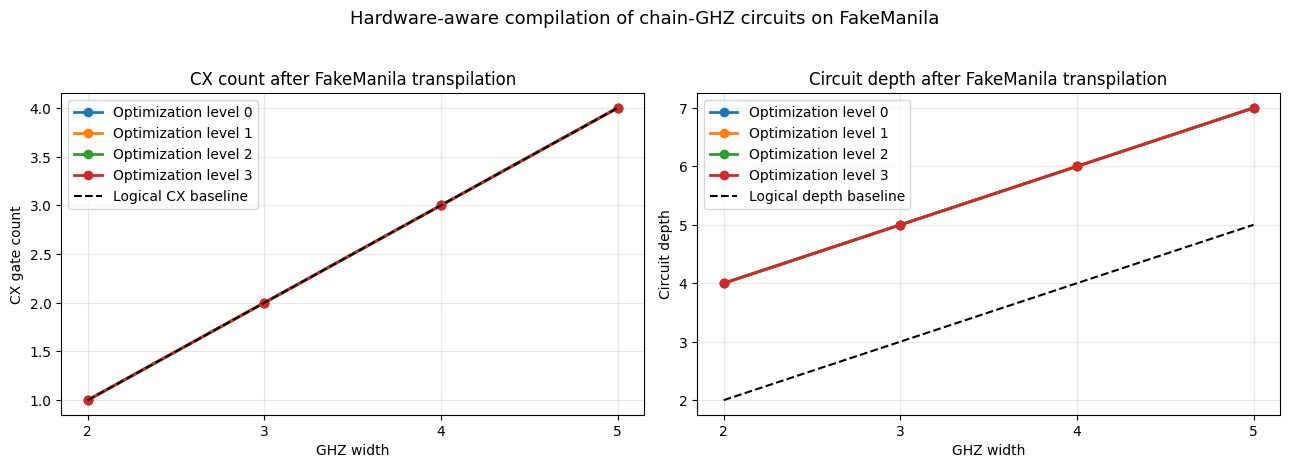

Saved: /content/q-reliability-lab/figures/section13_fake_manila_resources.png


In [153]:
## Transpilation resource figure

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)

for optimization_level in range(4):

    level_data = section13_transpilation_df[
        section13_transpilation_df["optimization_level"] == optimization_level
    ].sort_values("n_qubits")


    axes[0].plot(
        level_data["n_qubits"],
        level_data["physical_cx"],
        marker="o",
        linewidth=2,
        label=f"Optimization level {optimization_level}",
    )


    axes[1].plot(
        level_data["n_qubits"],
        level_data["physical_depth"],
        marker="o",
        linewidth=2,
        label=f"Optimization level {optimization_level}",
    )


widths = sorted(section13_transpilation_df["n_qubits"].unique())


# Original chain-GHZ circuit has n - 1 logical CX gates
axes[0].plot(
    widths,
    [n_qubits - 1 for n_qubits in widths],
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Logical CX baseline",
)


# Oiginal chain-GHZ logical depth is n
axes[1].plot(
    widths,
    widths,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Logical depth baseline",
)


axes[0].set_title("CX count after FakeManila transpilation")
axes[0].set_xlabel("GHZ width")
axes[0].set_ylabel("CX gate count")
axes[0].set_xticks(widths)
axes[0].grid(alpha=0.3)
axes[0].legend()


axes[1].set_title("Circuit depth after FakeManila transpilation")
axes[1].set_xlabel("GHZ width")
axes[1].set_ylabel("Circuit depth")
axes[1].set_xticks(widths)
axes[1].grid(alpha=0.3)
axes[1].legend()


fig.suptitle(
    "Hardware-aware compilation of chain-GHZ circuits on FakeManila",
    y=1.03,
    fontsize=13,
)

plt.tight_layout()

figure_path = PROJECT_ROOT / "figures" / "section13_fake_manila_resources.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", figure_path)


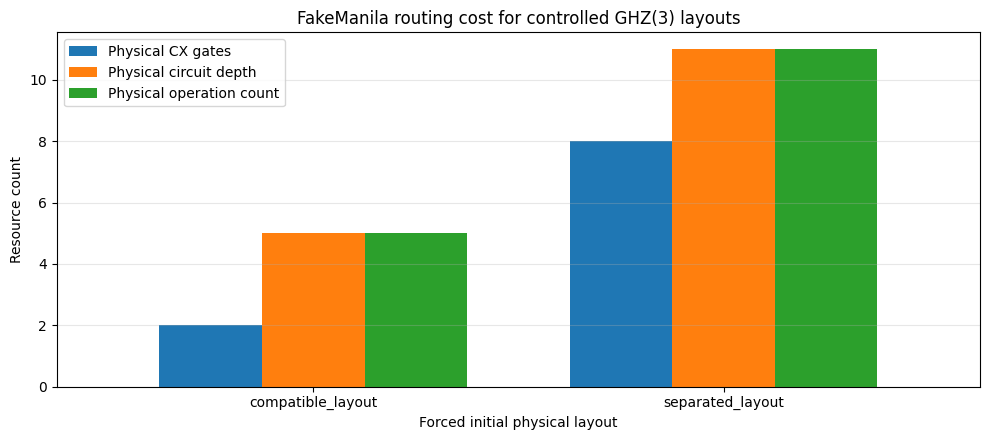

Saved: /content/q-reliability-lab/figures/section13_fake_manila_controlled_layout_comparison.png


In [154]:
#### Controlled compatible versus separated layout figure
layout_plot_df = section13_layout_df.set_index("layout_case")[
    [
        "physical_cx",
        "physical_depth",
        "physical_size",
    ]
]


ax = layout_plot_df.plot(
    kind="bar",
    figsize=(10, 4.5),
    rot=0,
    width=0.75,
)

ax.set_title("FakeManila routing cost for controlled GHZ(3) layouts")
ax.set_xlabel("Forced initial physical layout")
ax.set_ylabel("Resource count")
ax.grid(axis="y", alpha=0.3)
ax.legend(
    [
        "Physical CX gates",
        "Physical circuit depth",
        "Physical operation count",
    ]
)

plt.tight_layout()

layout_figure_path = (
    PROJECT_ROOT
    / "figures"
    / "section13_fake_manila_controlled_layout_comparison.png"
)


plt.savefig(
    layout_figure_path,
    dpi=300,
    bbox_inches="tight",
)


plt.show()

print("Saved:", layout_figure_path)


In [155]:
section13_transpilation_df.to_csv(
    PROJECT_ROOT / "results" / "section13_fake_manila_transpilation.csv",
    index=False,
)

section13_layout_df.to_csv(
    PROJECT_ROOT / "results" / "section13_fake_manila_layout_comparison.csv",
    index=False,
)

print("Section 13 FakeManila results and figures saved")

Section 13 FakeManila results and figures saved


### INTERPRETING THE RESULTS

FakeManilaV2 used to check how physical connectivity and gate-set contraints affect the compilation of the logical GHZ circuits. The backend has 5 physical qubits connected asa bidirectional linear chain.

Q_0 <- Q_1 <- Q_2 <- Q_3 <- Q_$

**Note: I measure compiled resources, not noisy fidelity or real-hardware performance**

#### Unfolder GHZ chains
For GHZ widths (n=2,3,4,5), optimization levels 0-3 produced identical physical CX counts, depths and total operation counts:

- N_CX,physical = n-1
- D_physical = n+2
- N_operations,physical = n+2.

The original GHZ preparation already uses nearest-neighbor CX interactions, so a compatible physical layout introduced no additional CX routing cost. Initial and final mappings were equal in every baseline case...

Some optimization levels selected different physical layouts..but this didnt change the measured resource counts. Means, higher optimization effort provided no gate-count or depth reduction for these circuits under the selected backend and seed.

#### Controlled physical-layout comparison

Checked the logical GHZ(3) circuit, backend, optimization level 0,and transpiler seed fixed, changing only the requested initial physical layout.

| Metric | Compatible `[0, 1, 2]` | Separated `[0, 2, 4]` |
|---|---:|---:|
| Physical CX gates | 2 | 8 |
| Physical depth | 5 | 11 |
| Physical operation count | 5 | 11 |
| Extra CX gates relative to the logical circuit | 0 | 6 |
| Final logical-to-physical mapping | `[0, 1, 2]` | `[1, 3, 4]` |

The compatible placement directly supported both required CX interactions. The separated placement required routing through intermediate physical qubits.

The separated circuit drawing contains two three-CX SWAP decompositions, accounting for the six additional CX gates:

N_CX,physical = 2 + 2(3) = 8.

Routing moved logical q_0 from Q_0 to Q_1 and logical q_1 from Q_2 to Q_3, and logical q_2 remained at Q_4. The final mapping `[1, 3, 4]` records these output positions.

Relative to the compatible compiled circuit, **the separated placement increased CX count by 300%, from 2 to 8**. Depth and total operation count each increased by 120%, from 5 to 11. The single-qubit operation counts remained unchanged: two `rz` gates and one `sx` gate. The resource difference therefore came from routing, not a different Hadamard decomposition.

#### In short
For the normal GHZ chain,FakeManila did not need extra CX gates because the circuit already follows the backend's nearest-neighbor line. The compiler still increased depth by two layers because the logical Hadamard had to be expressed using FakeManila's native `rz` and `sx` gates.

The controlled GHZ(3) layout test shows why placement matters. Starting the same logical circuit on separated physical qubits forced Qiskit to route the state through the device. This added 6 CX gates and increased the compiled depth by another 6 layers. With a compatible placement this routing cost was avoided.

Which simply means the physical qubit layout mattered more than changing the optimization level. The `logical_ghz_fidelity = 1.0` value only confirms that the original logical GHZ circuit is correct

## 14. Final Results

**Evidence!!**

Again, to clarify
- Prepared-state reference: How accurately did I reconstruct the noisy state?
- Ideal GHZ+ target: How close is the estimate to the intended ideal result?

 Future: Will read about M3 and execution-adapter extensions


In [156]:
assert "PROJECT_ROOT" in globals(), "Use the existing project session"
assert "CONFIG" in globals(), "Existing CONFIG is missing"

PROJECT_ROOT = Path(PROJECT_ROOT)
assert PROJECT_ROOT.is_dir(), f"Project folder missing: {PROJECT_ROOT}"

# Inspecting the current dataframes
frames = {
    name: value for name, value in list(globals().items())
    if isinstance(value, pd.DataFrame)
}

display(pd.DataFrame([
    {"dataframe": name, "rows": len(df), "columns": list(df.columns)}
    for name, df in sorted(frames.items())
]))

display(pd.DataFrame([
    {"file": str(p.relative_to(PROJECT_ROOT)), "bytes": p.stat().st_size}
    for p in sorted(PROJECT_ROOT.rglob("*"))
    if p.is_file() and p.suffix.lower() in {".csv", ".png", ".json", ".ipynb"}
]))

print("Project root:", PROJECT_ROOT)

,dataframe,rows,columns
0,_146,16,"[width, method, repeats, mean_fidelity, estima..."
1,analysis_comparison_df,2,"[analysis_rotations, fidelity_estimate, prepar..."
2,artifact_manifest_df,10,"[file, dataframe_source, rows, columns, verified]"
3,baseline,80,"[width, repeat_id, seed, baseline_fidelity_est..."
4,baseline_metrics,8,"[reference, width, unmitigated_mae, unmitigate..."
...,...,...,...
58,treatment,80,"[width, repeat_id, seed, fidelity_estimate, si..."
59,zne_comparison_df,4,"[method, fidelity_estimate, absolute_error_to_..."
60,zne_fidelity_df,3,"[noise_scale, raw_population, raw_coherence, r..."
61,zne_fit_summary_df,2,"[series, slope_per_scale, zero_noise_intercept]"


,file,bytes
0,figures/section13_fake_manila_controlled_layou...,118370
1,figures/section13_fake_manila_resources.png,273522
2,figures/section14_accuracy_vs_shot_cost.png,297945
3,results/advanced_experiment_config.json,441
4,results/controlled_ghz3_pilot_raw.csv,3428
5,results/controlled_ghz3_pilot_summary.csv,500
6,results/ghz3_dephasing_check.csv,168
7,results/ghz3_readout_calibration.csv,257
8,results/ghz3_readout_mitigation_pilot.csv,470
9,results/ghz3_zne_fit_summary_pilot.csv,164


Project root: /content/q-reliability-lab


In [157]:
results_dir = PROJECT_ROOT / "results"
figures_dir = PROJECT_ROOT / "figures"
results_dir.mkdir(exist_ok=True)
figures_dir.mkdir(exist_ok=True)

artifacts = {
    "section12_method_results.csv": ("benchmark_method_results_df", 320),
    "section12_scale_results.csv": ("benchmark_scale_results_df", 240),
    "section12_raw_counts.csv": ("benchmark_raw_counts_df", 1080),
    "section12_calibration_records.csv": ("benchmark_calibration_df", 280),
    "section12_method_summary.csv": ("section12_summary_df", 16),
    "section12_paired_errors.csv": ("paired_error_df", 80),
    "section12_paired_summary.csv": ("paired_summary_df", 4),
    "section12_calibration_summary.csv": ("calibration_summary_df", 4),
    "section13_fake_manila_transpilation.csv": ("section13_transpilation_df", 16),
    "section13_fake_manila_layout_comparison.csv": ("section13_layout_df", 2),
}

manifest_rows = []

for filename, (name, expected_rows) in artifacts.items():
    path = results_dir / filename
    frame = globals().get(name)

    if isinstance(frame, pd.DataFrame):
        assert len(frame) == expected_rows, f"Unexpected row count: {name}"
        frame.to_csv(path, index=False)

    assert path.is_file(), f"Missing {filename}; stop and recover the artifact"
    saved = pd.read_csv(path)
    assert len(saved) == expected_rows, f"Unexpected saved rows: {filename}"

    if isinstance(frame, pd.DataFrame):
        # Reset index name attributes to prevent assertion failure from loss of metadata in roundtrip
        df_to_test = frame.reset_index(drop=True)
        if df_to_test.columns.name is not None:
            df_to_test.columns.name = None
        pd.testing.assert_frame_equal(
            df_to_test, saved,
            check_dtype=False, check_exact=False,
        )

    manifest_rows.append({
        "file": f"results/{filename}",
        "dataframe_source": name,
        "rows": len(saved),
        "columns": json.dumps(list(saved.columns)),
        "verified": True,
    })

artifact_manifest_df = pd.DataFrame(manifest_rows)
display(artifact_manifest_df[["file", "rows", "verified"]])

,file,rows,verified
0,results/section12_method_results.csv,320,True
1,results/section12_scale_results.csv,240,True
2,results/section12_raw_counts.csv,1080,True
3,results/section12_calibration_records.csv,280,True
4,results/section12_method_summary.csv,16,True
5,results/section12_paired_errors.csv,80,True
6,results/section12_paired_summary.csv,4,True
7,results/section12_calibration_summary.csv,4,True
8,results/section13_fake_manila_transpilation.csv,16,True
9,results/section13_fake_manila_layout_compariso...,2,True


### Artifact check-gate

In [158]:
method_df = pd.read_csv(results_dir / "section12_method_results.csv")
raw_df = pd.read_csv(results_dir / "section12_raw_counts.csv")

methods = [
    "unmitigated",
    "readout_mitigation",
    "zne_only",
    "readout_mitigation_plus_zne",
]

assert set(method_df["method"]) == set(methods)
assert set(method_df["width"]) == {2, 3, 4, 5}
assert not method_df.duplicated(["width", "repeat_id", "method"]).any()

for (_, _), group in method_df.groupby(["width", "method"]):
    assert set(group["repeat_id"]) == set(range(20))

numeric_columns = [
    "fidelity_estimate", "prepared_state_reference",
    "target_shots", "calibration_shots", "total_shots",
]
assert np.isfinite(method_df[numeric_columns].to_numpy()).all()

# Check standalone estimator costs
base_shots = (method_df["width"] + 1) * 512
uses_zne = method_df["method"].isin(methods[2:])
uses_readout = method_df["method"].isin([methods[1], methods[3]])

expected_target = base_shots * np.where(uses_zne, 3, 1)
expected_calibration = np.where(uses_readout, 1024, 0)

assert (method_df["target_shots"] == expected_target).all()
assert (method_df["calibration_shots"] == expected_calibration).all()
assert (method_df["total_shots"] == expected_target + expected_calibration).all()

assert raw_df["counts_json"].map(
    lambda value: sum(json.loads(value).values())
).eq(512).all()

print("Saved artifact structure and shot checks passed")

Saved artifact structure and shot checks passed


In [105]:
summary_parts = []

for reference, target in [
    ("prepared", method_df["prepared_state_reference"]),
    ("ideal", 1.0),
]:
    data = method_df.assign(error=method_df["fidelity_estimate"] - target)
    data["absolute_error"] = data["error"].abs()

    summary = data.groupby(["width", "method"], as_index=False).agg(
        repeats=("repeat_id", "nunique"),
        mean_fidelity=("fidelity_estimate", "mean"),
        estimate_std=("fidelity_estimate", "std"),
        bias=("error", "mean"),
        mae=("absolute_error", "mean"),
        rmse=("error", lambda x: np.sqrt(np.mean(x**2))),
        mean_total_shots=("total_shots", "mean"),
    )
    summary["reference"] = reference
    summary_parts.append(summary)

section14_reference_summary_df = pd.concat(summary_parts, ignore_index=True)
section14_reference_summary_df.to_csv(
    results_dir / "section14_reference_summary.csv", index=False
)

display(section14_reference_summary_df.round(6))

,width,method,repeats,mean_fidelity,estimate_std,bias,mae,rmse,mean_total_shots,reference
0,2,readout_mitigation,20,0.990459,0.017310,0.002694,0.013671,0.017086,2560.0,prepared
1,2,readout_mitigation_plus_zne,20,1.001991,0.019571,0.014226,0.020039,0.023796,5632.0,prepared
2,2,unmitigated,20,0.874902,0.008495,-0.112863,0.112863,0.113166,1536.0,prepared
3,2,zne_only,20,0.884607,0.011597,-0.103158,0.103158,0.103776,4608.0,prepared
4,3,readout_mitigation,20,0.966751,0.021196,-0.008073,0.018029,0.022180,3072.0,prepared
5,3,readout_mitigation_plus_zne,20,0.993696,0.022928,0.018873,0.025061,0.029251,7168.0,prepared
6,3,unmitigated,20,0.807422,0.008974,-0.167402,0.167402,0.167630,2048.0,prepared
7,3,zne_only,20,0.828927,0.011433,-0.145897,0.145897,0.146322,6144.0,prepared
8,4,readout_mitigation,20,0.963261,0.022154,0.001213,0.016584,0.021627,3584.0,prepared
9,4,readout_mitigation_plus_zne,20,0.995731,0.023206,0.033683,0.035008,0.040572,8704.0,prepared


### Paired method comparisons

Compare the methods within each identical experiment (width,seed,repeat_id)

**Note: Negative delta means the method col specified improves on the baseline**

In [159]:
paired_baselines = {"readout_mitigation": "unmitigated", "zne_only": "unmitigated", "readout_mitigation_plus_zne": "unmitigated"}
paired_parts = []

for reference, target in [("prepared", method_df["prepared_state_reference"]), ("ideal", 1.0)]:
    paired = method_df.copy()
    paired["signed_error"] = paired["fidelity_estimate"] - target
    paired["absolute_error"] = paired["signed_error"].abs()
    paired["squared_error"] = paired["signed_error"] ** 2
    paired["reference"] = reference

    index_cols = ["width", "repeat_id", "seed"]

    baseline = (
        paired[paired["method"] == "unmitigated"]
        .loc[:, index_cols + ["fidelity_estimate", "signed_error", "absolute_error", "squared_error", "total_shots"]]
        .rename(columns={
            "fidelity_estimate": "baseline_fidelity_estimate",
            "signed_error": "baseline_signed_error",
            "absolute_error": "baseline_absolute_error",
            "squared_error": "baseline_squared_error",
            "total_shots": "baseline_total_shots",
        })
    )

    for method, baseline_method in paired_baselines.items():
        treatment = paired[paired["method"] == method].loc[:, index_cols + ["fidelity_estimate", "signed_error", "absolute_error", "squared_error", "total_shots"]].copy()

        comparison = treatment.merge(baseline, on=index_cols, how="inner", validate="one_to_one")
        comparison["method"] = method
        comparison["baseline_method"] = baseline_method
        comparison["fidelity_delta_vs_baseline"] = comparison["fidelity_estimate"] - comparison["baseline_fidelity_estimate"]
        comparison["signed_error_delta_vs_baseline"] = comparison["signed_error"] - comparison["baseline_signed_error"]
        comparison["absolute_error_delta_vs_baseline"] = comparison["absolute_error"] - comparison["baseline_absolute_error"]
        comparison["squared_error_delta_vs_baseline"] = comparison["squared_error"] - comparison["baseline_squared_error"]
        comparison["additional_shots_vs_baseline"] = comparison["total_shots"] - comparison["baseline_total_shots"]
        comparison["reference"] = reference

        paired_parts.append(comparison)

section14_paired_method_comparison_df = pd.concat(paired_parts, ignore_index=True)

section14_paired_method_summary_df = (
    section14_paired_method_comparison_df
    .groupby(["reference", "width", "baseline_method", "method"], as_index=False)
    .agg(
        repeats=("repeat_id", "nunique"),
        mean_fidelity_gain=("fidelity_delta_vs_baseline", "mean"),
        fidelity_gain_std=("fidelity_delta_vs_baseline", "std"),
        mean_signed_error_change=("signed_error_delta_vs_baseline", "mean"),
        mean_mae_change=("absolute_error_delta_vs_baseline", "mean"),
        mean_squared_error_change=("squared_error_delta_vs_baseline", "mean"),
        improved_mae_fraction=("absolute_error_delta_vs_baseline", lambda x: (x < 0).mean()),
        mean_additional_shots=("additional_shots_vs_baseline", "mean"),
    )
)

section14_paired_method_summary_df["signed_sqrt_mean_squared_error_change"] = (
    np.sign(section14_paired_method_summary_df["mean_squared_error_change"]) * np.sqrt(section14_paired_method_summary_df["mean_squared_error_change"].abs())
)

section14_paired_method_comparison_df.to_csv(results_dir / "section14_paired_method_comparison.csv", index=False)
section14_paired_method_summary_df.to_csv(results_dir / "section14_paired_method_summary.csv", index=False)

display(section14_paired_method_summary_df.sort_values(["reference", "width", "method"]).round(6))

,reference,width,baseline_method,method,repeats,mean_fidelity_gain,fidelity_gain_std,mean_signed_error_change,mean_mae_change,mean_squared_error_change,improved_mae_fraction,mean_additional_shots,signed_sqrt_mean_squared_error_change
0,ideal,2,unmitigated,readout_mitigation,20,0.115557,0.013680,0.115557,-0.109807,-0.015342,1.00,1024.0,-0.123864
1,ideal,2,unmitigated,readout_mitigation_plus_zne,20,0.127088,0.015331,0.127088,-0.109443,-0.015350,1.00,4096.0,-0.123896
2,ideal,2,unmitigated,zne_only,20,0.009705,0.005835,0.009705,-0.009705,-0.002275,0.95,3072.0,-0.047693
3,ideal,3,unmitigated,readout_mitigation,20,0.159329,0.018565,0.159329,-0.159158,-0.035631,1.00,1024.0,-0.188761
4,ideal,3,unmitigated,readout_mitigation_plus_zne,20,0.186275,0.020292,0.186275,-0.173722,-0.036624,1.00,5120.0,-0.191373
5,ideal,3,unmitigated,zne_only,20,0.021505,0.006707,0.021505,-0.021505,-0.007773,1.00,4096.0,-0.088162
6,ideal,4,unmitigated,readout_mitigation,20,0.210234,0.018294,0.210234,-0.207785,-0.059315,1.00,1024.0,-0.243546
7,ideal,4,unmitigated,readout_mitigation_plus_zne,20,0.242703,0.017820,0.242703,-0.228982,-0.060601,1.00,6144.0,-0.246172
8,ideal,4,unmitigated,zne_only,20,0.024607,0.006292,0.024607,-0.024607,-0.011460,1.00,5120.0,-0.107050
9,ideal,5,unmitigated,readout_mitigation,20,0.250446,0.017105,0.250446,-0.250446,-0.087861,1.00,1024.0,-0.296414


### Accuracy-Cost decision table

Negative/positive results are measured relative to the unmitigated baseline

In [160]:
baseline_metrics = (
    section14_reference_summary_df
    .query("method == 'unmitigated'")
    .loc[:, ["reference", "width", "mae", "rmse", "mean_total_shots"]]
    .rename(columns={"mae": "unmitigated_mae", "rmse": "unmitigated_rmse", "mean_total_shots": "unmitigated_mean_total_shots"})
)

section14_accuracy_cost_df = section14_reference_summary_df.merge(baseline_metrics, on=["reference", "width"], how="left", validate="many_to_one").copy()

section14_accuracy_cost_df["mae_reduction_vs_unmitigated"] = section14_accuracy_cost_df["unmitigated_mae"] - section14_accuracy_cost_df["mae"]
section14_accuracy_cost_df["mae_reduction_percent"] = 100 * section14_accuracy_cost_df["mae_reduction_vs_unmitigated"] / section14_accuracy_cost_df["unmitigated_mae"]
section14_accuracy_cost_df["additional_shots_vs_unmitigated"] = section14_accuracy_cost_df["mean_total_shots"] - section14_accuracy_cost_df["unmitigated_mean_total_shots"]
section14_accuracy_cost_df["shot_multiplier_vs_unmitigated"] = section14_accuracy_cost_df["mean_total_shots"] / section14_accuracy_cost_df["unmitigated_mean_total_shots"]

section14_accuracy_cost_df["mae_reduction_per_1000_additional_shots"] = np.where(
    section14_accuracy_cost_df["additional_shots_vs_unmitigated"] > 0,
    1000 * section14_accuracy_cost_df["mae_reduction_vs_unmitigated"] / section14_accuracy_cost_df["additional_shots_vs_unmitigated"],
    np.nan,
)

section14_accuracy_cost_df["mae_rank_within_reference_width"] = (
    section14_accuracy_cost_df.groupby(["reference", "width"])["mae"].rank(method="dense", ascending=True)
)

section14_accuracy_cost_df["decision_role"] = np.select(
    [
        section14_accuracy_cost_df["method"].eq("unmitigated"),
        section14_accuracy_cost_df["reference"].eq("prepared") & section14_accuracy_cost_df["method"].eq("readout_mitigation"),
        section14_accuracy_cost_df["reference"].eq("ideal") & section14_accuracy_cost_df["width"].eq(2) & section14_accuracy_cost_df["method"].eq("readout_mitigation"),
        section14_accuracy_cost_df["reference"].eq("ideal") & section14_accuracy_cost_df["width"].isin([3, 4, 5]) & section14_accuracy_cost_df["method"].eq("readout_mitigation_plus_zne"),
    ],
    [
        "baseline",
        "recommended_prepared_state_estimator",
        "recommended_ideal_target_estimator",
        "recommended_ideal_target_estimator",
    ],
    default="alternative",
)

section14_accuracy_cost_df.to_csv(results_dir / "section14_accuracy_cost_decision_table.csv", index=False)

display(
    section14_accuracy_cost_df[
        [
            "reference",
            "width",
            "method",
            "mae",
            "rmse",
            "mae_reduction_vs_unmitigated",
            "mae_reduction_percent",
            "mean_total_shots",
            "additional_shots_vs_unmitigated",
            "shot_multiplier_vs_unmitigated",
            "mae_reduction_per_1000_additional_shots",
            "mae_rank_within_reference_width",
            "decision_role",
        ]
    ]
    .sort_values(["reference", "width", "mae_rank_within_reference_width"])
    .round(6)
)

,reference,width,method,mae,rmse,mae_reduction_vs_unmitigated,mae_reduction_percent,mean_total_shots,additional_shots_vs_unmitigated,shot_multiplier_vs_unmitigated,mae_reduction_per_1000_additional_shots,mae_rank_within_reference_width,decision_role
16,ideal,2,readout_mitigation,0.015291,0.019382,0.109807,87.776826,2560.0,1024.0,1.666667,0.107233,1.0,recommended_ideal_target_estimator
17,ideal,2,readout_mitigation_plus_zne,0.015655,0.019179,0.109443,87.485779,5632.0,4096.0,3.666667,0.026719,2.0,alternative
19,ideal,2,zne_only,0.115393,0.115945,0.009705,7.757611,4608.0,3072.0,3.000000,0.003159,3.0,alternative
18,ideal,2,unmitigated,0.125098,0.125371,0.000000,0.000000,1536.0,0.0,1.000000,NaN,4.0,baseline
21,ideal,3,readout_mitigation_plus_zne,0.018857,0.023220,0.173722,90.208375,7168.0,5120.0,3.500000,0.033930,1.0,recommended_ideal_target_estimator
20,ideal,3,readout_mitigation,0.033420,0.039144,0.159158,82.645770,3072.0,1024.0,1.500000,0.155427,2.0,alternative
23,ideal,3,zne_only,0.171073,0.171436,0.021505,11.166751,6144.0,4096.0,3.000000,0.005250,3.0,alternative
22,ideal,3,unmitigated,0.192578,0.192777,0.000000,0.000000,2048.0,0.0,1.000000,NaN,4.0,baseline
25,ideal,4,readout_mitigation_plus_zne,0.017991,0.023018,0.228982,92.715508,8704.0,6144.0,3.400000,0.037269,1.0,recommended_ideal_target_estimator
24,ideal,4,readout_mitigation,0.039188,0.042614,0.207785,84.132782,3584.0,1024.0,1.400000,0.202915,2.0,alternative


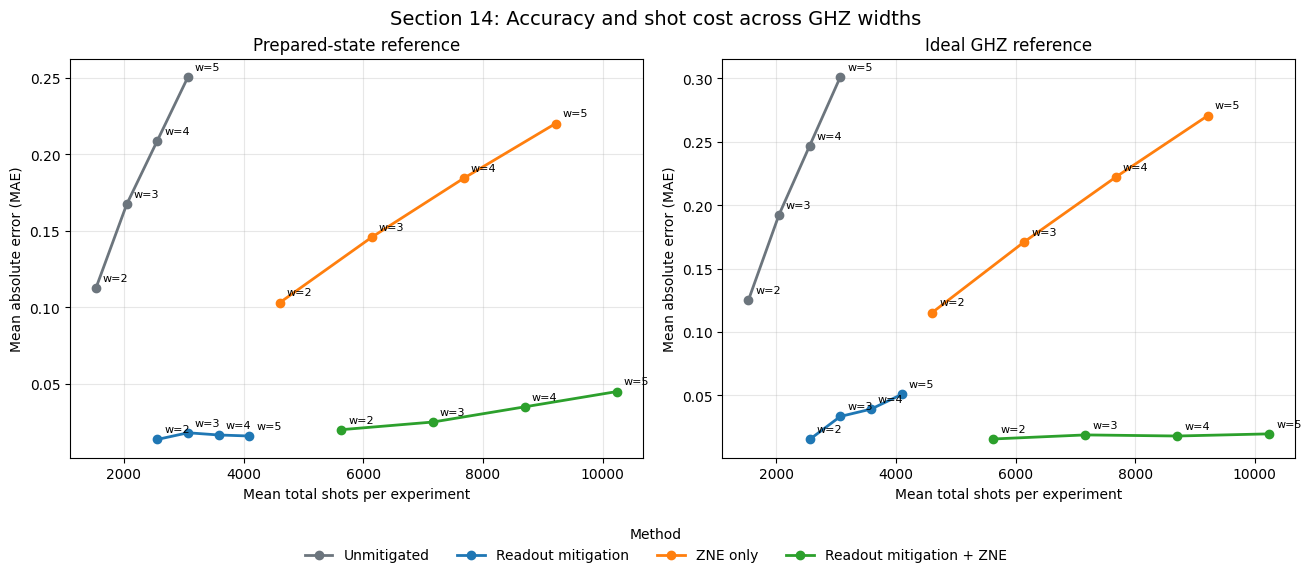

In [161]:
labels = {
    "unmitigated": "Unmitigated",
    "readout_mitigation": "Readout mitigation",
    "zne_only": "ZNE only",
    "readout_mitigation_plus_zne": "Readout mitigation + ZNE",
}

colors = {
    "unmitigated": "#6c757d",
    "readout_mitigation": "#1f77b4",
    "zne_only": "#ff7f0e",
    "readout_mitigation_plus_zne": "#2ca02c",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

for ax, reference in zip(axes, ["prepared", "ideal"]):
    for method, label in labels.items():
        data = (
            section14_accuracy_cost_df
            .query("reference == @reference and method == @method")
            .sort_values("width")
        )

        ax.plot(
            data["mean_total_shots"],
            data["mae"],
            "o-",
            lw=2,
            ms=6,
            color=colors[method],
            label=label,
        )

        for _, row in data.iterrows():
            ax.annotate(
                f'w={int(row["width"])}',
                (row["mean_total_shots"], row["mae"]),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=8,
            )

    ax.set(
        title=(
            "Prepared-state reference"
            if reference == "prepared"
            else "Ideal GHZ reference"
        ),
        xlabel="Mean total shots per experiment",
        ylabel="Mean absolute error (MAE)",
    )
    ax.grid(alpha=0.3)

handles, legend_labels = axes[1].get_legend_handles_labels()
fig.legend(
    handles,
    legend_labels,
    title="Method",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=4,
    frameon=False,
)

fig.suptitle(
    "Section 14: Accuracy and shot cost across GHZ widths",
    fontsize=14,
)

fig.savefig(
    figures_dir / "section14_accuracy_vs_shot_cost.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Accuracy and Shot Cost interpretation

Each point is the mean MAE from 20 matched repeats for one method and GHZ width. Lines connect widths from 2 to 5 qubits.. they are not fixed-shot
budget curves. Shot counts include target measurements and calibration where needed. ZNE uses scales 1,3,5 so its total cost is higher.

For the prepared-state reference, readout mitigation has the lowest MAE at every width. At GHZ(5), it gives MAE 0.015910 using 4,096 shots, compared
with MAE 0.044976 and 10,240 shots for readout mitigation plus ZNE.

For the ideal reference, readout mitigation has the lowest MAE at GHZ(2). Readout mitigation plus ZNE has the lowest observed MAE from GHZ(3) to
GHZ(5), but it uses more shots. At GHZ(5), its ideal-reference MAE is 0.019688 using 10,240 shots, compared with 0.050765 using 4,096 shots for
readout mitigation.

Error bars are not shown. The figure shows observed mean MAE over 20 repeats and does not demonstrate statistical significance.

## 15. GITHUB REPO PREP

Will record results, figures, README, requirements, and `.gitignore` files in a local repository folder, then pushes them to GitHub.

Repository:
`ghz_fidelity_error_mitigation_benchmark`

In [162]:
import shutil
import subprocess

GITHUB_USERNAME = "Jahprance"
GITHUB_EMAIL = "dhyaneswarpraneshraj@gmail.com"
REPO_NAME = "ghz_fidelity_error_mitigation_benchmark"

repo_dir = Path("/content") / REPO_NAME

assert PROJECT_ROOT.exists()
assert not repo_dir.exists(), (
    f"{repo_dir} already exists. Remove it only if it is an old unused copy."
)

subprocess.run(
    [
        "git",
        "clone",
        f"https://github.com/{GITHUB_USERNAME}/{REPO_NAME}.git",
        str(repo_dir),
    ],
    check=True,
)

for folder_name in ["results", "figures"]:
    shutil.copytree(
        PROJECT_ROOT / folder_name,
        repo_dir / folder_name,
    )

print("Repository cloned:", repo_dir)
print("Copied results and figures")

Repository cloned: /content/ghz_fidelity_error_mitigation_benchmark
Copied results and figures


### Create project files

README, dependency list and `.gitignore`. Will upload the ipynb manually

In [163]:
readme_text = """# GHZ-State Fidelity Benchmarking and Quantum Error Mitigation

**Author:** Praneshraj Tiruppur Nagarajan Dhyaneswar
**Tools:** Python, Qiskit, Qiskit Aer
**Scope:** Controlled simulation and FakeManila compilation. No quantum
hardware execution is included.

## Objective

This project investigates how reliably GHZ-state fidelity can be estimated
from noisy finite-shot measurements, and whether error-mitigation methods
improve the estimate enough to justify their additional sampling cost.

A higher reported fidelity is not automatically a better estimate. I compare
each method with a defined reference and include the target-measurement and
calibration shots required by that method.

## References used

The final comparison uses two references:

- **Prepared-state reference:** exact fidelity of the noisy scale-1 state,
  calculated from the simulated density matrix before analysis rotations and
  readout.
- **Ideal reference:** fidelity 1.0 for the intended noiseless GHZ-plus
  state.

The references answer different questions. A method can move an estimate
closer to the ideal target while moving it farther from the noisy state that
was actually prepared.

## Workflow

The notebook builds the benchmark step by step:

1. Prepare GHZ-plus states from 2 to 5 qubits and verify ideal populations
   and target fidelity.
2. Compare GHZ+, GHZ- and balanced classical mixture to show why
   computational-basis populations alone cannot fully describe GHZ fidelity.
3. Validate measurement rotations and reconstruct fidelity using endpoint
   populations and parity measurements that recover GHZ coherence.
4. Use density-matrix simulation to separate preparation noise from bias
   introduced by noisy analysis rotations.
5. Run finite-shot pilots under ideal, readout-only, depolarizing-only and
   combined-noise conditions.
6. Calibrate local readout assignment matrices and correct measured
   distributions without clipping negative quasi-probabilities.
7. Fold only the GHZ preparation circuit at scales 1, 3, 5 verify that
   the ideal output is unchanged and fit linear ZNE estimates.
8. Compare unmitigated, readout mitigation, ZNE only and readout mitigation
   plus ZNE over 20 matched repetitions for each width.
9. Compare bias, MAE, RMSE, estimate variation, paired error changes,
   calibration behaviour and total-shot cost.
10. Transpile GHZ circuits on FakeManila across optimization levels and
    forced physical layouts.

The main benchmark contains 80 matched width-repeat experiments and 320
method-result rows. Readout calibration is repeated for every run, and its
cost is included in the total-shot comparison.

## Main findings

For the noisy prepared-state reference, readout mitigation gave the lowest
MAE for every tested width from 2 to 5 qubits. Its MAE ranged from 0.013671
to 0.018029, and it improved absolute error over the unmitigated result in
every matched run.

For GHZ(5), the unmitigated prepared-reference MAE was 0.250655. Readout
mitigation reduced it to 0.015910, a 93.65% reduction. This used 4,096 total
shots, compared with 3,072 shots for the unmitigated method because it
included 1,024 calibration shots.

For the ideal reference, readout mitigation had the lowest observed MAE at
GHZ(2). At GHZ(3) through GHZ(5) readout mitigation plus ZNE had the lowest
observed MAE, but required substantially more shots. At GHZ(5), its
ideal-reference MAE was 0.019688 using 10,240 shots. Its prepared-reference
MAE was 0.044976, which was higher than readout mitigation alone.

For the FakeManila compilation check, optimization levels 0 to 3 produced
the same CX counts and circuit depths for the standard GHZ chains. In a
controlled GHZ(3) layout comparison, changing the initial layout from
`[0, 1, 2]` to `[0, 2, 4]` increased physical CX count from 2 to 8 and
compiled circuit depth from 5 to 11 because routing was required.

## Accuracy and shot cost

Each point in the final accuracy-cost figure is the mean MAE from 20 matched
repetitions for one method and GHZ width. Lines connect widths from 2 to 5
qubits; they are not fixed-shot-budget curves.

Shot counts include target measurements and calibration where applicable.
ZNE uses measurements at scales 1, 3, and 5, so its total shot cost is
higher. Error bars are not shown; the figure shows observed mean MAE and
does not demonstrate statistical significance.

## Repository structure

```text
.
├── figures/       Generated PNG figures
├── notebooks/     Final executed Colab notebook
├── results/       CSV results and experiment configuration
├── README.md      Project overview
└── requirements.txt
```

## Reproduction

1. Install dependencies:

   ```bash
   pip install -r requirements.txt
   ```

2. Open the notebook in `notebooks/`.
3. Run cells in order.

The notebook records package versions, configuration, simulator seeds,
calibration records, raw counts, and saved result tables.

## Scope and limitations

These results apply to the selected GHZ circuits, controlled noise model,
calibration approach, and shot budgets. The project uses Aer simulation and
FakeManila transpilation.. it does not execute on real quantum hardware.

Readout errors are independent across qubits. ZNE folds only the GHZ
preparation circuit at scales 1, 3, and 5. Analysis rotations and readout are
not folded, so the ZNE intercept should not be treated as a completely
noise-free measurement result.

The methods use the same shots per target measurement setting, but different
total shot budgets. The results describe observed average behaviour over 20
repeats and do not establish statistical significance.
"""

In [164]:
(repo_dir / "README.md").write_text(readme_text, encoding="utf-8")

requirements_text = """qiskit==2.5.2
qiskit-aer==0.17.2
numpy==2.1.3
pandas==2.2.3
scipy==1.16.3
matplotlib==3.10.0
seaborn==0.13.2
"""

(repo_dir / "requirements.txt").write_text(
    requirements_text,
    encoding="utf-8",
)

(repo_dir / ".gitignore").write_text(
    """.ipynb_checkpoints/
__pycache__/
*.pyc
.env
""",
    encoding="utf-8",
)

print("README.md, requirements.txt, and .gitignore created")

README.md, requirements.txt, and .gitignore created


In [165]:
subprocess.run(
    ["git", "-C", str(repo_dir), "status", "--short"],
    check=True,
)

print("\nFiles that will be added:")
for path in sorted(repo_dir.rglob("*")):
    if path.is_file() and ".git" not in path.parts:
        print(path.relative_to(repo_dir))


Files that will be added:
.gitignore
README.md
figures/section13_fake_manila_controlled_layout_comparison.png
figures/section13_fake_manila_resources.png
figures/section14_accuracy_vs_shot_cost.png
requirements.txt
results/advanced_experiment_config.json
results/controlled_ghz3_pilot_raw.csv
results/controlled_ghz3_pilot_summary.csv
results/ghz3_dephasing_check.csv
results/ghz3_readout_calibration.csv
results/ghz3_readout_mitigation_pilot.csv
results/ghz3_zne_fit_summary_pilot.csv
results/ghz3_zne_method_comparison_pilot.csv
results/ghz3_zne_scale_fidelity_estimates.csv
results/ghz3_zne_scale_measurements_raw.csv
results/ideal_ghz3_sampled_pilot.csv
results/section12_calibration_records.csv
results/section12_calibration_summary.csv
results/section12_method_results.csv
results/section12_method_summary.csv
results/section12_paired_errors.csv
results/section12_paired_summary.csv
results/section12_raw_counts.csv
results/section12_scale_results.csv
results/section13_fake_manila_layout_comp

In [166]:
from getpass import getpass

subprocess.run(
    ["git", "-C", str(repo_dir), "config", "user.name", "Praneshraj Tiruppur Nagarajan Dhyaneswar"],
    check=True,
)

subprocess.run(
    ["git", "-C", str(repo_dir), "config", "user.email", GITHUB_EMAIL],
    check=True,
)

subprocess.run(
    ["git", "-C", str(repo_dir), "add", "README.md", "requirements.txt", ".gitignore", "results", "figures"],
    check=True,
)

subprocess.run(
    [
        "git",
        "-C",
        str(repo_dir),
        "commit",
        "-m",
        "Add GHZ fidelity benchmark results and figures",
    ],
    check=True,
)

token = getpass("Paste GitHub token here: ")

authenticated_url = (
    f"https://{GITHUB_USERNAME}:{token}"
    f"@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git"
)

subprocess.run(
    [
        "git",
        "-C",
        str(repo_dir),
        "push",
        authenticated_url,
        "main",
    ],
    check=True,
)

del token
print("GitHub push completed")

Paste GitHub token here: ··········
GitHub push completed
